# 🧪 Интеллектуальная классификация душистых веществ
---
Этот ноутбук реализует **гибридный подход** к классификации химической продукции:
1. **CatBoost**: Мгновенная разметка строк с высокой уверенностью.
2. **LLM (Qwen 2.5)**: Глубокий анализ сложных и неоднозначных описаний.

### Основные этапы:
- 📂 Подготовка данных и путей
- 🤖 Обучение и применение классификатора CatBoost
- 🧠 Доразметка через LLM
- 📊 Визуализация результатов

## 🛠️ Настройка окружения

In [12]:
%%capture
!pip install pandas numpy catboost requests tqdm matplotlib seaborn scikit-learn openpyxl

## 📦 Импорт библиотек

In [3]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
import requests
import json
import re
import os
from tqdm import tqdm 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

# Душистые в-ва

## 🔍 Этап 1: Первичная классификация (LLM Batch Analysis)Рандомные 500 строк делим на группы по 30 и оцениваем категории

In [14]:
file_path = r'data/fragrances_input.xlsx'
df_fragrances = pd.read_excel(file_path)

unique_descriptions = df_fragrances['Описание 350 крт'].dropna().drop_duplicates()
sample_size = min(500, len(unique_descriptions))
sample_texts = unique_descriptions.sample(sample_size, random_state=42).tolist()

batch_size = 30
batches = [sample_texts[i:i + batch_size] for i in range(0, len(sample_texts), batch_size)]

# Убираем идеальный шаблон. Пусть начинает с нуля и потеет!
current_categories = "Список пуст. Начни создавать его с первой партии."

def update_categories(text_batch, current_list, batch_num):
    url = "http://127.0.0.1:1234/v1/chat/completions"
    
    PROMPT = f"""Ты — химический аналитик-детализатор. Твоя цель — создать максимально ПОДРОБНЫЙ классификатор душистых веществ (нужно собрать 25-30 узких бизнес-категорий).
    
    ТЕКУЩИЙ НАКОПЛЕННЫЙ СПИСОК:
    {current_list}
    
    НОВЫЕ ТОВАРЫ ДЛЯ АНАЛИЗА (Партия {batch_num}):
    {text_batch}
    
    ЖЕСТКИЙ ПРИКАЗ:
    1. Изучи партию. Найди в ней специфичные ниши (например: ароматизаторы для табака/вейпов, отдушки для автохимии, коптильные смеси, добавки для кормов, сырье для напитков, чистые химические изоляты и т.д.).
    2. Ты ОБЯЗАН добавить как минимум 1-2 новые УЗКИЕ категории к текущему списку на основе новых товаров. 
    3. НЕ УКРУПНЯЙ! Если видишь пищевые — раздели их на "для выпечки", "для напитков", "для соусов".
    4. Выведи ВЕСЬ обновленный список целиком в виде маркерного списка: "- [Узкая категория] : [Кратко, что сюда входит]". Никакого лишнего текста!
    """

    payload = {
        "model": "qwen2.5-7b-instruct",
        "messages": [
            {"role": "user", "content": PROMPT}
        ],
        "temperature": 0.5, # Оставляем креативность для придумывания новых названий рубрик
        "max_tokens": 1500  # Даем много места для длинного списка
    }
    
    try:
        response = requests.post(url, json=payload)
        if response.status_code != 200:
            return f"Ошибка сервера: {response.text}"
            
        data = response.json()
        if 'choices' in data:
            return data['choices'][0]['message']['content'].strip()
        else:
            return "Ошибка формата ответа."
    except Exception as e:
        return f"Ошибка связи: {e}"

print(f"Подготовлено {len(sample_texts)} строк. Разбито на {len(batches)} партий.")
print("Запускаю форсированный сбор узких категорий...\n")

for i, batch in enumerate(batches):
    print(f"Пытаю нейросеть партией {i+1} из {len(batches)}...")
    batch_text = "\n".join([f"{j+1}. {text}" for j, text in enumerate(batch)])
    
    result = update_categories(batch_text, current_categories, i+1)
    
    if "Ошибка" in result:
        print(f"❌ ОСТАНОВКА: {result}")
        break
    else:
        current_categories = result
        print(f"✅ Партия {i+1} обработана! Список растет.")

print("\n==================================================")
print("ФИНАЛЬНЫЙ РАСШИРЕННЫЙ КЛАССИФИКАТОР (ПОСЛЕ 500 СТРОК):")
print("==================================================")
print(current_categories)

Подготовлено 500 строк. Разбито на 17 партий.
Запускаю форсированный сбор узких категорий...

Пытаю нейросеть партией 1 из 17...
✅ Партия 1 обработана! Список растет.
Пытаю нейросеть партией 2 из 17...
✅ Партия 2 обработана! Список растет.
Пытаю нейросеть партией 3 из 17...
✅ Партия 3 обработана! Список растет.
Пытаю нейросеть партией 4 из 17...
✅ Партия 4 обработана! Список растет.
Пытаю нейросеть партией 5 из 17...
✅ Партия 5 обработана! Список растет.
Пытаю нейросеть партией 6 из 17...
✅ Партия 6 обработана! Список растет.
Пытаю нейросеть партией 7 из 17...
✅ Партия 7 обработана! Список растет.
Пытаю нейросеть партией 8 из 17...
✅ Партия 8 обработана! Список растет.
Пытаю нейросеть партией 9 из 17...
✅ Партия 9 обработана! Список растет.
Пытаю нейросеть партией 10 из 17...
✅ Партия 10 обработана! Список растет.
Пытаю нейросеть партией 11 из 17...
✅ Партия 11 обработана! Список растет.
Пытаю нейросеть партией 12 из 17...
✅ Партия 12 обработана! Список растет.
Пытаю нейросеть партией 

## Обучающая выборка
Забиваем через llm выборку для обучения catboost

In [2]:
# 1. Загружаем исходный файл
file_path = r'data/fragrances_input.xlsx'
df = pd.read_excel(file_path)

# БЕРЕМ ТОЛЬКО ПЕРВЫЕ 2000 СТРОК ДЛЯ ОБУЧЕНИЯ CATBOOST
df_llm = df.head(2000).copy()
df_llm['Продукт единый'] = None

output_path = r'O:\chemistry\Teacher_Qwen_2000.xlsx'

# 2. ПРОМПТ ДЛЯ ДУШИСТЫХ ВЕЩЕСТВ (Из нашего прошлого шага)
SYSTEM_PROMPT = """Ты — эксперт-аналитик химического рынка. Классифицируй товары по списку.
Верни строго JSON с одним полем: "Продукт единый".

СПИСОК КАТЕГОРИЙ (выбирай СТРОГО из него):
- Ароматизаторы пищевые (жидкие)
- Ароматизаторы пищевые (сухие/порошок)
- Ароматизаторы спиртосодержащие (напитки)
- Ароматизаторы коптильные (Жидкий дым)
- Ароматизаторы для табачной промышленности
- Ароматизаторы для вейпов и ЭСДН
- Ароматические капсулы/сферики (табак)
- Отдушки для парфюмерии (базы/композиции)
- Отдушки для косметики и мыла
- Отдушки для бытовой химии
- Отдушки для автохимии
- Эфирные масла (натуральные/нативные)
- Эфирные масла (реконструированные/синтетика)
- Растительные экстракты и олеорезины
- Химические изоляты (чистые в-ва: ментол, ванилин)
- Смеси душистых веществ (пром. сырье)
- Препараты для кондитерских изделий и жвачки
- Препараты для производства соусов и кетчупов
- Сырье и концентраты для напитков
- Вспомогательные в-ва (растворители/носители)
- Пищевые добавки комплексные
- Кормовые добавки (животные)
- Ароматизаторы фармацевтические
- Образцы для лабораторных исследований
- Прочее (не классифицировано)

ИНСТРУКЦИЯ:
- Слово "ОЛЕОРЕЗИН" / "OLEORESIN" / "ЭКСТРАКТ" -> "Растительные экстракты и олеорезины"
- "Сферические капсулы" -> "Ароматические капсулы/сферики (табак)"
- Для сауны и свечей -> "Отдушки для бытовой химии"
- Слова "ПИЩЕВЫЕ", "ДОБАВКА", "ДЛЯ КОНДИТЕРСКОЙ" -> НИКОГДА не относи к эфирным маслам!
"""

def classify_row(text):
    if pd.isna(text) or text == "": return "Пусто"
    try:
        response = requests.post(
            "http://127.0.0.1:1234/v1/chat/completions",
            json={"model": "qwen2.5-7b-instruct", 
                  "messages": [{"role": "system", "content": SYSTEM_PROMPT}, 
                               {"role": "user", "content": f"Вход: {text}"}],
                  "temperature": 0.0},
            timeout=10)
        res_text = response.json()['choices'][0]['message']['content']
        match = re.search(r'\{.*\}', res_text, re.DOTALL)
        parsed = json.loads(match.group(0)) if match else json.loads(res_text)
        return parsed.get("Продукт единый", "Ошибка")
    except: return "Ошибка"

# 3. ЗАПУСК QWEN С АВТОСОХРАНЕНИЕМ
print("Qwen начал разметку 2000 строк. Можно прервать в любой момент.")
for i, row in df_llm.iterrows():
    if pd.notna(df_llm.at[i, 'Продукт единый']): continue
    
    df_llm.at[i, 'Продукт единый'] = classify_row(row['Описание 350 крт'])
    
    if (i + 1) % 100 == 0:
        df_llm.to_excel(output_path, index=False)
        print(f"✅ Обработано {i + 1}/2000 строк. Сохранено.")

# Очистка от цифр и мусора (как мы делали в офлайн-скрипте)
df_llm['Продукт единый'] = df_llm['Продукт единый'].astype(str).str.replace(r'[^а-яА-Яa-zA-Z0-9\(\)\/\-\s:]', '', regex=True)
df_llm.to_excel(output_path, index=False)
print("ФИНАЛ 1 ЭТАПА! Эталонная база для обучения готова.")

Qwen начал разметку 2000 строк. Можно прервать в любой момент.
✅ Обработано 100/2000 строк. Сохранено.
✅ Обработано 200/2000 строк. Сохранено.
✅ Обработано 300/2000 строк. Сохранено.
✅ Обработано 400/2000 строк. Сохранено.
✅ Обработано 500/2000 строк. Сохранено.
✅ Обработано 600/2000 строк. Сохранено.
✅ Обработано 700/2000 строк. Сохранено.
✅ Обработано 800/2000 строк. Сохранено.
✅ Обработано 900/2000 строк. Сохранено.
✅ Обработано 1000/2000 строк. Сохранено.
✅ Обработано 1100/2000 строк. Сохранено.
✅ Обработано 1200/2000 строк. Сохранено.
✅ Обработано 1300/2000 строк. Сохранено.
✅ Обработано 1400/2000 строк. Сохранено.
✅ Обработано 1500/2000 строк. Сохранено.
✅ Обработано 1600/2000 строк. Сохранено.
✅ Обработано 1700/2000 строк. Сохранено.
✅ Обработано 1800/2000 строк. Сохранено.
✅ Обработано 1900/2000 строк. Сохранено.
✅ Обработано 2000/2000 строк. Сохранено.
ФИНАЛ 1 ЭТАПА! Эталонная база для обучения готова.


## Чиним категории
Для обучающей выборки

In [7]:
# Загружаем наш эталонный файл с 2000 строками
file_path = 'Teacher_Qwen_2000.xlsx'
df = pd.read_excel(file_path)

# Функция-санитар для починки 360 проблемных строк
def fix_qwen_errors(val):
    if pd.isna(val): return "Прочее (не классифицировано)"
    val_str = str(val).strip()
    
    # 1. Возвращаем украденную пунктуацию
    if "пром сырье" in val_str or val_str == "Смеси душистых веществ" or "промышленное сырье" in val_str:
        return "Смеси душистых веществ (пром. сырье)"
    if "ментол ванилин" in val_str or "чистые в-ва" in val_str:
        return "Химические изоляты (чистые в-ва: ментол, ванилин)"
    
    # 2. Лечим галлюцинации по ключевым словам
    val_lower = val_str.lower()
    if "косметики и мыла" in val_lower: 
        return "Отдушки для косметики и мыла"
    if "парфюмерии (базы" in val_lower or "парфюмерная композиция" in val_lower: 
        return "Отдушки для парфюмерии (базы/композиции)"
    if "табак" in val_lower or "сигарет" in val_lower: 
        return "Ароматизаторы для табачной промышленности"
    if "корм" in val_lower: 
        return "Кормовые добавки (животные)"
    if "порошок" in val_lower or "сухие" in val_lower: 
        return "Ароматизаторы пищевые (сухие/порошок)"
    if "пищевые ароматизаторы" in val_lower or "пищевой" in val_lower: 
        return "Ароматизаторы пищевые (жидкие)"
    if "капсулы" in val_lower or "сферики" in val_lower: 
        return "Ароматические капсулы/сферики (табак)"
        
    return val_str

print("Начинаю лечение категорий...")
df['Продукт единый'] = df['Продукт единый'].apply(fix_qwen_errors)

# Ищем, что осталось со словом "Ошибка" и меняем на "Прочее"
df.loc[df['Продукт единый'] == 'Ошибка', 'Продукт единый'] = "Прочее (не классифицировано)"

# Перезаписываем наш эталонный файл
df.to_excel(file_path, index=False)
print("ИДЕАЛЬНО! Файл вылечен и готов к подаче в CatBoost.")

Начинаю лечение категорий...
ИДЕАЛЬНО! Файл вылечен и готов к подаче в CatBoost.


## Обучаем Кота
То в чём он сомневается помечаем для нейронки

In [15]:
# 1. ЗАГРУЖАЕМ ДАННЫЕ
file_path_full = r'data/fragrances_input.xlsx' 
file_path_teacher = 'Teacher_Qwen_2000.xlsx' # Наш эталон

df_full = pd.read_excel(file_path_full)
df_teacher = pd.read_excel(file_path_teacher)

# Очищаем трейн-базу от пустых
df_train = df_teacher.dropna(subset=['Описание 350 крт', 'Продукт единый']).copy()

# 2. УЧИМ КОТА (Без балансировки, чтобы не портить общую точность)
X_train = df_train[['Описание 350 крт']]
y_train = df_train['Продукт единый']

model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    text_features=['Описание 350 крт'],
    random_seed=42,
    verbose=0 # Отключаем вывод текста обучения
)

print("Быстро обучаю CatBoost...")
model.fit(X_train, y_train)

# 3. РАЗМЕЧАЕМ ОСТАВШИЕСЯ ДАННЫЕ
# Убираем из большого файла те 2000 строк, которые уже разметил Qwen
df_predict = df_full.iloc[len(df_teacher):].copy()
X_unseen = df_predict[['Описание 350 крт']]

print(f"Приступаю к разметке {len(X_unseen)} новых строк...")

# Кот выдает предсказания
preds_classes = model.predict(X_unseen)
# И Кот выдает матрицу вероятностей (насколько он уверен)
preds_proba = model.predict_proba(X_unseen)

# Берем максимальную вероятность для каждой строки
max_probas = np.max(preds_proba, axis=1)

# 4. ЛОГИКА ДОВЕРИЯ (ПОРОГ 70%)
CONFIDENCE_THRESHOLD = 0.70

final_predictions = []
catboost_success = 0
need_llm = 0

for i in range(len(preds_classes)):
    if max_probas[i] >= CONFIDENCE_THRESHOLD:
        # Уверен? Записываем ответ Кота!
        final_predictions.append(preds_classes[i][0])
        catboost_success += 1
    else:
        # Сомневается? Оставляем пустым для ИИ
        final_predictions.append("ТРЕБУЕТСЯ LLM")
        need_llm += 1

df_predict['Продукт единый'] = final_predictions

# 5. СКЛЕИВАЕМ ВСЁ В ОДИН ФАЙЛ
df_result = pd.concat([df_teacher, df_predict], ignore_index=True)

# Сохраняем результат
output_path = r'output/hybrid_result.xlsx'
df_result.to_excel(output_path, index=False)

print("\n" + "="*50)
print(f"🎉 ГОТОВО! Файл сохранен: {output_path}")
print(f"⚡ Размечено моментально (CatBoost): {catboost_success} строк")
print(f"🧠 Отложено для нейросети (LLM): {need_llm} строк")
print("="*50)

Быстро обучаю CatBoost...
Приступаю к разметке 5045 новых строк...

🎉 ГОТОВО! Файл сохранен: O:\chemistry\Hybrid_Result.xlsx
⚡ Размечено моментально (CatBoost): 3486 строк
🧠 Отложено для нейросети (LLM): 1559 строк


## 🧠 Этап 2: Финальная доразметка через LLM

In [17]:
# 1. ЗАГРУЖАЕМ НАШ ГИБРИДНЫЙ ФАЙЛ
file_path = r'output/hybrid_result.xlsx'
df = pd.read_excel(file_path)

output_path = r'output/final_result.xlsx'

# 2. ПРОМПТ ДЛЯ QWEN (с нашими жесткими правилами)
SYSTEM_PROMPT = """Ты — эксперт-аналитик химического рынка. Классифицируй товары по списку.
Верни строго JSON с одним полем: "Продукт единый".

СПИСОК КАТЕГОРИЙ (выбирай СТРОГО из него):
- Ароматизаторы пищевые (жидкие)
- Ароматизаторы пищевые (сухие/порошок)
- Ароматизаторы спиртосодержащие (напитки)
- Ароматизаторы коптильные (Жидкий дым)
- Ароматизаторы для табачной промышленности
- Ароматизаторы для вейпов и ЭСДН
- Ароматические капсулы/сферики (табак)
- Отдушки для парфюмерии (базы/композиции)
- Отдушки для косметики и мыла
- Отдушки для бытовой химии
- Отдушки для автохимии
- Эфирные масла (натуральные/нативные)
- Эфирные масла (реконструированные/синтетика)
- Растительные экстракты и олеорезины
- Химические изоляты (чистые в-ва: ментол, ванилин)
- Смеси душистых веществ (пром. сырье)
- Препараты для кондитерских изделий и жвачки
- Препараты для производства соусов и кетчупов
- Сырье и концентраты для напитков
- Вспомогательные в-ва (растворители/носители)
- Пищевые добавки комплексные
- Кормовые добавки (животные)
- Ароматизаторы фармацевтические
- Образцы для лабораторных исследований
- Прочее (не классифицировано)

ИНСТРУКЦИЯ:
- Слово "ОЛЕОРЕЗИН" / "OLEORESIN" / "ЭКСТРАКТ" -> "Растительные экстракты и олеорезины"
- "Сферические капсулы" -> "Ароматические капсулы/сферики (табак)"
- Для сауны и свечей -> "Отдушки для бытовой химии"
- Слова "ПИЩЕВЫЕ", "ДОБАВКА", "ДЛЯ КОНДИТЕРСКОЙ" -> НИКОГДА не относи к эфирным маслам!
"""

def classify_row_llm(text):
    if pd.isna(text) or text == "": return "Пусто"
    try:
        response = requests.post(
            "http://127.0.0.1:1234/v1/chat/completions",
            json={
                "model": "qwen2.5-7b-instruct", 
                "messages": [
                    {"role": "system", "content": SYSTEM_PROMPT}, 
                    {"role": "user", "content": f"Вход: {text}"}
                ],
                "temperature": 0.0
            },
            timeout=15 
        )
        res_text = response.json()['choices'][0]['message']['content']
        match = re.search(r'\{.*\}', res_text, re.DOTALL)
        parsed = json.loads(match.group(0)) if match else json.loads(res_text)
        
        # --- НАШ ЖЕСТКИЙ ПРЕДОХРАНИТЕЛЬ ---
        result = parsed.get("Продукт единый", "Ошибка")
        
        # Если ИИ выдал список (например ["Категория 1"]), берем первый элемент
        if isinstance(result, list):
            result = result[0] if len(result) > 0 else "Ошибка"
            
        # Жестко превращаем в строку и убираем лишние пробелы по краям
        return str(result).strip()
        
    except Exception:
        return "Ошибка"

# 3. ЗАПУСК ДОБИВКИ (только для сложных случаев)
mask = df['Продукт единый'] == "ТРЕБУЕТСЯ LLM"
rows_to_process = mask.sum()
print(f"Начинаю обработку {rows_to_process} сложных строк через Qwen...")

processed_count = 0

for i, row in df[mask].iterrows():
    result = classify_row_llm(row['Описание 350 крт'])
    df.at[i, 'Продукт единый'] = result
    
    processed_count += 1
    
    # Автосохранение каждые 50 строк (чтобы ничего не потерять)
    if processed_count % 50 == 0:
        df.to_excel(output_path, index=False)
        print(f"🧠 Обработано {processed_count}/{rows_to_process} сложных строк. Прогресс сохранен.")

# 4. ФИНАЛЬНАЯ ОЧИСТКА ОТ ПУНКТУАЦИОННОГО МУСОРА
def final_clean(val):
    val_str = str(val).strip()
    if "пром сырье" in val_str: return "Смеси душистых веществ (пром. сырье)"
    if "ментол ванилин" in val_str: return "Химические изоляты (чистые в-ва: ментол, ванилин)"
    return val_str

df['Продукт единый'] = df['Продукт единый'].apply(final_clean)

# Финальное сохранение
df.to_excel(output_path, index=False)
print("\n" + "="*50)
print(f"🏆 ВСЕ 7000 СТРОК ПОЛНОСТЬЮ РАЗМЕЧЕНЫ!")
print(f"Итоговый файл лежит здесь: {output_path}")
print("="*50)

Начинаю обработку 1559 сложных строк через Qwen...
🧠 Обработано 50/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 100/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 150/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 200/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 250/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 300/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 350/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 400/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 450/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 500/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 550/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 600/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 650/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 700/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 750/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 800/1559 сложных строк. Прогресс сохранен.
🧠 Обработано 850/1559 сложных строк. Прогресс сохранен

## Финальная чистка категорий

In [18]:
# 1. Загружаем ваш итоговый файл
file_path = r'output/final_result.xlsx'
df = pd.read_excel(file_path)

def clean_final_garbage(val):
    if pd.isna(val): return "Прочее (не классифицировано)"
    
    val_str = str(val).strip().lower() # Переводим всё в нижний регистр для удобного поиска
    
    # --- СЛОВАРЬ ЖЕСТКОГО МАППИНГА ---
    # Порядок важен! Сначала ищем специфичные слова, потом общие.
    mapping = {
        "сухие/порошок": "Ароматизаторы пищевые (сухие/порошок)",
        "реконструированные/синтетика": "Эфирные масла (реконструированные/синтетика)",
        "натуральные/нативные": "Эфирные масла (натуральные/нативные)",
        "нативные": "Эфирные масла (натуральные/нативные)",
        "мыловар": "Отдушки для косметики и мыла", 
        "косметики и мыла": "Отдушки для косметики и мыла",
        "парфюмерии": "Отдушки для парфюмерии (базы/композиции)",
        "бытовой химии": "Отдушки для бытовой химии",
        "автохимии": "Отдушки для автохимии",
        "вейп": "Ароматизаторы для вейпов и ЭСДН",
        "напитков": "Сырье и концентраты для напитков", 
        "табач": "Ароматизаторы для табачной промышленности",
        "коптиль": "Ароматизаторы коптильные (Жидкий дым)",
        "фармацевт": "Ароматизаторы фармацевтические",
        "капсулы": "Ароматические капсулы/сферики (табак)",
        "сферики": "Ароматические капсулы/сферики (табак)",
        "корм": "Кормовые добавки (животные)",
        "добавки комплексные": "Пищевые добавки комплексные",
        "кондитер": "Препараты для кондитерских изделий и жвачки",
        "соусов": "Препараты для производства соусов и кетчупов",
        "кетчуп": "Препараты для производства соусов и кетчупов",
        "экстракты": "Растительные экстракты и олеорезины",
        "олеорезин": "Растительные экстракты и олеорезины",
        "изоляты": "Химические изоляты (чистые в-ва: ментол, ванилин)",
        "ментол": "Химические изоляты (чистые в-ва: ментол, ванилин)",
        "пром. сырье": "Смеси душистых веществ (пром. сырье)",
        "промышленное сырье": "Смеси душистых веществ (пром. сырье)",
        "жидкие": "Ароматизаторы пищевые (жидкие)",
        "пищевых продуктов": "Ароматизаторы пищевые (жидкие)",
        "ароматизаторы пищевые": "Ароматизаторы пищевые (жидкие)", # Фоллбэк для пищевых
        "смеси душистых веществ": "Смеси душистых веществ (пром. сырье)" # Самый широкий фоллбэк
    }

    # Ищем совпадения по ключам
    for key, correct_cat in mapping.items():
        if key in val_str:
            return correct_cat
            
    # Если написано "Ошибка" или совсем ничего не подошло
    return "Прочее (не классифицировано)"

print("Запускаю финальную стерилизацию категорий...")

df['Продукт единый'] = df['Продукт единый'].apply(clean_final_garbage)

# Сохраняем идеально чистый файл
clean_path = r'O:\chemistry\PERFECT_FINAL_7000.xlsx'
df.to_excel(clean_path, index=False)

print("\n=== ТОП-10 ИТОГОВЫХ КАТЕГОРИЙ ===")
print(df['Продукт единый'].value_counts().head(10))
print(f"\nВсе данные очищены и сохранены в файл: {clean_path}")
print("Можно строить сводные таблицы и нести отчет!")

Запускаю финальную стерилизацию категорий...

=== ТОП-10 ИТОГОВЫХ КАТЕГОРИЙ ===
Продукт единый
Ароматизаторы пищевые (жидкие)               3071
Смеси душистых веществ (пром. сырье)         1247
Отдушки для парфюмерии (базы/композиции)      673
Ароматизаторы пищевые (сухие/порошок)         525
Ароматизаторы для табачной промышленности     500
Отдушки для косметики и мыла                  395
Отдушки для бытовой химии                     140
Эфирные масла (натуральные/нативные)           99
Прочее (не классифицировано)                   98
Ароматизаторы для вейпов и ЭСДН                85
Name: count, dtype: int64

Все данные очищены и сохранены в файл: O:\chemistry\PERFECT_FINAL_7000.xlsx
Можно строить сводные таблицы и нести отчет!


# Верификация Целлюлоза

## Разметка обучающей выборки через LLM
По уже имеющимся категориям

In [10]:
# 1. Загружаем файл
file_path = 'data.xlsx'
df = pd.read_excel(file_path)

column_to_analyze = 'Описание 350 крт'

# Выбираем 2000 случайных строк (или меньше, если в файле не хватает)
sample_size = min(2000, len(df))
df_sample = df.sample(n=sample_size, random_state=42).copy()

# Создаем пустую колонку заранее
df_sample['продукт единый'] = None

# 2. Идеальный Мега-Промпт (ОБНОВЛЕННЫЙ И БРОНЕБОЙНЫЙ)
SYSTEM_PROMPT = """Ты — ведущий химический аналитик. Твоя задача — классифицировать таможенные описания производных целлюлозы. Верни строго валидный JSON с 1 полем: "Продукт единый". Никакого лишнего текста.

ПРАВИЛО: Выбери СТРОГО ОДНО значение из списка категорий ниже (копируй символ в символ, буква 'Ц' означает Целлюлоза). Если сомневаешься или продукта нет в списке, пиши "Прочее (не эфиры/МКЦ или н.д.)".

РАЗРЕШЕННЫЙ СПИСОК КАТЕГОРИЙ:
- Ацетат фталат Ц
- Ацетат Ц
- Ацетопропинат Ц (АПЦ)
- Бутират ацетат Ц
- Гидроксипропил Ц(ГПЦ) и произв
- Гидроксипропилметил Ц (ГПМЦ) и произв
- Гидроксипропилметил Ц фталат
- Гидроксиэтил Ц(ГЭЦ) и произв
- Готовые смеси для оболочек лекарств
- ГПМЦ + Мод. Крахмал
- Диэтиламиноэтил Ц (DEAE)
- Карбоксиметил Ц(КМЦ) и произв
- Коллойдная Ц
- Метил Ц + крахмал
- Метил Ц и произв 
- Метилгидроксиэтил Ц(МГЭЦ)
- Микрокрист Ц(МКЦ)
- н.д. эфиры Ц 
- Нитро Ц и произв
- Поликватрениумы (поликатион Ц)
- Прочее (не эфиры/МКЦ или н.д.)
- Смесь Микрокрист Ц(МКЦ) и Карбоксиметил Ц(КМЦ)
- Смешаные грузы эфиров
- Триацетат Ц
- Этил Ц
- Этилгидрокси этил Ц

ЖЕСТКИЕ ПОДСКАЗКИ ДЛЯ КЛАССИФИКАЦИИ (ЧИТАЙ ВНИМАТЕЛЬНО!):
- ❗️ Если в тексте есть "Opadry", "Aquapolish", "Colorcon", "пленочное покрытие", "оболочка" — это СТРОГО "Готовые смеси для оболочек лекарств", ДАЖЕ ЕСЛИ в составе указан ГПМЦ или HPMC!
- ❗️ Строго различай HPMC (ГПМЦ) и MHEC (МГЭЦ)! Если видишь "MHEC", "Метилгидроксиэтил", "WALOCEL" — это СТРОГО "Метилгидроксиэтил Ц(МГЭЦ)". Не путай с ГПМЦ!
- "Кроскармеллоза", "CMC", "Карбоксиметил", "BLANOSE" -> "Карбоксиметил Ц(КМЦ) и произв"
- "HPMC", "Гипромеллоза", "METOLOSE", "METHOCEL" -> "Гидроксипропилметил Ц (ГПМЦ) и произв" (но если это оболочка, см. правило выше!)
- "HEC", "Гидроксиэтилцеллюлоза", "NATROSOL", "CELLOSIZE", "Tylose" -> "Гидроксиэтил Ц(ГЭЦ) и произв"
- "Polyquaternium", "ПОЛИКВАТЕРНИУМ", "DEKAQUAT" -> "Поликватрениумы (поликатион Ц)"
- "Klucel", "HPC", "Гидроксипропилцеллюлоза" -> "Гидроксипропил Ц(ГПЦ) и произв"
- "Фильтры", "сигарет" -> "Ацетат Ц"

ПРИМЕР 1:
Вход: "OPADRY II WHITE СУХАЯ СМЕСЬ ДЛЯ ПЛЕНОЧНОГО ПОКРЫТИЯ ОБОЛОЧКОЙ, СОДЕРЖИТ ГИПРОМЕЛЛОЗУ..."
Выход: {"Продукт единый": "Готовые смеси для оболочек лекарств"}

ПРИМЕР 2:
Вход: "СТРОИТЕЛЬНАЯ ДОБАВКА WALOCEL (MHEC) МЕТИЛГИДРОКСИЭТИЛЦЕЛЛЮЛОЗА..."
Выход: {"Продукт единый": "Метилгидроксиэтил Ц(МГЭЦ)"}
"""

# 3. Функция общения с локальной нейросетью (с защитой от обрывов)
def ask_qwen(text):
    if pd.isna(text) or text == "":
        return "Пусто"
    
    url = "http://127.0.0.1:1234/v1/chat/completions"
    
    payload = {
        "model": "qwen2.5-7b-instruct",
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": f"Вход: {text}"}
        ],
        "temperature": 0.0
    }
    
    # Пытаемся спросить ИИ до 3 раз, если сервер не отвечает сразу
    for attempt in range(3):
        try:
            response = requests.post(url, json=payload, timeout=60)
            result_text = response.json()['choices'][0]['message']['content']
            
            clean_json = re.search(r'\{.*\}', result_text, re.DOTALL)
            if clean_json:
                parsed = json.loads(clean_json.group(0))
            else:
                parsed = json.loads(result_text)
                
            return parsed.get("Продукт единый", "Ошибка формата")
                
        except Exception as e:
            if attempt == 2: # Если это была третья неудачная попытка
                return "Ошибка API"
            time.sleep(2) # Ждем 2 секунды перед повтором

# 4. Запускаем обработку в цикле
print(f"Запускаю анализ {sample_size} строк. Бэкап будет сохраняться каждые 100 строк...")

# Получаем список индексов для итерации
indices = df_sample.index.tolist()

for i, idx in enumerate(tqdm(indices, desc="Прогресс обработки")):
    text = df_sample.at[idx, column_to_analyze]
    
    # Спрашиваем нейросеть и записываем ответ в ячейку
    result = ask_qwen(text)
    df_sample.at[idx, 'продукт единый'] = result
    
    # Делаем бэкап каждые 100 строк
    if (i + 1) % 100 == 0:
        backup_df = df_sample[[column_to_analyze, 'продукт единый']]
        backup_df.to_excel('backup_checkpoint.xlsx', index=False)
        tqdm.write(f"💾 Сохранен бэкап: обработано {i + 1} из {sample_size} строк.")

# 5. Сохраняем финальный результат
df_final = df_sample[[column_to_analyze, 'продукт единый']]
output_file = 'training_sample_2000.xlsx'
df_final.to_excel(output_file, index=False)

print(f"\n🎉 Готово! Финальный результат сохранен в файл: {output_file}")
display(df_final.head(10))

Запускаю анализ 2000 строк. Бэкап будет сохраняться каждые 100 строк...


Прогресс обработки:   5%|██▉                                                        | 100/2000 [01:16<24:16,  1.30it/s]

💾 Сохранен бэкап: обработано 100 из 2000 строк.


Прогресс обработки:  10%|█████▉                                                     | 200/2000 [02:40<25:49,  1.16it/s]

💾 Сохранен бэкап: обработано 200 из 2000 строк.


...

Прогресс обработки:  95%|███████████████████████████████████████████████████████   | 1900/2000 [25:55<01:29,  1.12it/s]

💾 Сохранен бэкап: обработано 1900 из 2000 строк.


Прогресс обработки: 100%|██████████████████████████████████████████████████████████| 2000/2000 [27:09<00:00,  1.23it/s]

💾 Сохранен бэкап: обработано 2000 из 2000 строк.

🎉 Готово! Финальный результат сохранен в файл: training_sample_2000.xlsx


,Описание 350 крт,продукт единый
169,"""TYLOSE HX 6000 YG4""-ГИДРОФОБНО-МОДИФИЦИРОВАНН...",Гидроксиэтил Ц(ГЭЦ) и произв
8875,НИТРОЦЕЛЛЮЛОЗА РАСТВОРЕНАЯ В 30% ИЗОПРОПИЛОВОМ...,Нитро Ц и произв
16789,ЭФИРЫ ЦЕЛЛЮЛОЗЫ ПРОСТЫЕ:МЕТОЦЕЛ К15М PREMIUM Г...,Гидроксипропилметил Ц (ГПМЦ) и произв
2267,БУТИРАТ АЦЕТАТА ЦЕЛЛЮЛОЗЫ. CAS 9004-36-8=ЭФИР...,Ацетат Ц
15927,"ЭФИРЫ ЦЕЛЛЮЛОЗЫ ПРОСТЫЕ, НЕ ПРЕДНАЗНАЧЕНЫ ДЛЯ ...",Прочее (не эфиры/МКЦ или н.д.)
9304,ПИЩЕВАЯ ДОБАВКА - КАРБОКСИМЕТИЛЦЕЛЛЮЛОЗЫ НАТРИ...,Карбоксиметил Ц(КМЦ) и произв
828,E461 МЕТИЛЦЕЛЛЮЛОЗА (METILCELLULOSA) - ЭФИР МЕ...,Метил Ц и произв
7975,НАТРИЕВАЯ КАРБОМЕТИЛЦЕЛЛЮЛОЗА (КМЦ)(НАТРИЕВАЯ ...,Карбоксиметил Ц(КМЦ) и произв
15088,ЭФИРЫ ЦЕЛЛЮЛОЗЫ ПРОСТЫЕ В ПЕРВИЧНОЙ ФОРМЕ (ПОР...,Метилгидроксиэтил Ц(МГЭЦ)
14789,ЭФИРЫ ЦЕЛЛЮЛОЗЫ ПРОСТЫЕ - ВОДОРАСТВОРИМАЯ ГИДР...,Гидроксиэтил Ц(ГЭЦ) и произв


## Чиним категории

In [11]:
import pandas as pd

# Загружаем наш файл после обработки нейросетью
file_path = 'training_sample_2000.xlsx'
df = pd.read_excel(file_path)

target_col = 'продукт единый'

def fix_qwen_errors(val):
    if pd.isna(val): 
        return "Прочее (не эфиры/МКЦ или н.д.)"
    
    val_str = str(val).strip()
    val_lower = val_str.lower()
    
    # 0. Ловим ошибки API
    if "ошибка" in val_lower or "пусто" in val_lower or "error" in val_lower:
        return "Прочее (не эфиры/МКЦ или н.д.)"

    # 1. ОБНОВЛЕННЫЙ ЖЕСТКИЙ СЛОВАРЬ (Перехватываем новые фантазии Qwen)
    exact_mapping = {
        "ацетат бутират ц": "Бутират ацетат Ц",
        "ацетобутират ц": "Бутират ацетат Ц",
        "бутират целлюлозы": "Бутират ацетат Ц",
        "бутират целлюлозы cab381": "Бутират ацетат Ц",
        "коллоидная ц": "Коллойдная Ц",
        "метил гидроксипропил целлюлоза": "Гидроксипропилметил Ц (ГПМЦ) и произв", # ГПМЦ
        "метил гидроксиэтил ц(мгэц)": "Метилгидроксиэтил Ц(МГЭЦ)",
        "микрокрист ц(мкц) и произв": "Микрокрист Ц(МКЦ)",
        "н.д. эфиры ц": "н.д. эфиры Ц ", 
        "эфиры целлюлозы": "н.д. эфиры Ц ",
        "нитрат ц и произв": "Нитро Ц и произв",
        "нитраты целлюлозы": "Нитро Ц и произв",
        "этилгидроксиэтил ц": "Этилгидрокси этил Ц",
        "этиловый эфир целлюлозы": "Этил Ц",
        "целлюлоза": "Прочее (не эфиры/МКЦ или н.д.)",
        "полиакрилонатная целлюлоза": "Прочее (не эфиры/МКЦ или н.д.)" # Нестандартная производная
    }
    
    if val_lower in exact_mapping:
        return exact_mapping[val_lower]

    # 2. ПОИСК ПО ПОДСТРОКАМ (На всякий случай)
    if "мкц" in val_lower and "кмц" in val_lower:
        return "Смесь Микрокрист Ц(МКЦ) и Карбоксиметил Ц(КМЦ)"
    if "гпмц" in val_lower and "крахмал" in val_lower:
        return "ГПМЦ + Мод. Крахмал"
    if "метил" in val_lower and "крахмал" in val_lower:
        return "Метил Ц + крахмал"
    if "ацетат" in val_lower and "фталат" in val_lower:
        return "Ацетат фталат Ц"
    if "бутират" in val_lower and "ацетат" in val_lower:
        return "Бутират ацетат Ц"
    if "гидроксипропилметил" in val_lower and "фталат" in val_lower:
        return "Гидроксипропилметил Ц фталат"
    if "карбоксиметил" in val_lower or "кмц" in val_lower or "cmc" in val_lower:
        return "Карбоксиметил Ц(КМЦ) и произв"
    if "гидроксипропилметил" in val_lower or "гпмц" in val_lower or "hpmc" in val_lower:
        return "Гидроксипропилметил Ц (ГПМЦ) и произв"
    if "гидроксиэтил" in val_lower or "гэц" in val_lower or "hec" in val_lower:
        return "Гидроксиэтил Ц(ГЭЦ) и произв"
    if "метилгидроксиэтил" in val_lower or "мгэц" in val_lower:
        return "Метилгидроксиэтил Ц(МГЭЦ)"
    if "этилгидрокси" in val_lower:
        return "Этилгидрокси этил Ц"
    if "гидроксипропил" in val_lower or "гпц" in val_lower:
        return "Гидроксипропил Ц(ГПЦ) и произв"
    if "микрокрист" in val_lower or "мкц" in val_lower or "mcc" in val_lower:
        return "Микрокрист Ц(МКЦ)"
    if "поликватерниум" in val_lower or "поликатион" in val_lower or "polyquaternium" in val_lower:
        return "Поликватрениумы (поликатион Ц)"
    if "готовые смеси" in val_lower or "оболоч" in val_lower or "пленочн" in val_lower:
        return "Готовые смеси для оболочек лекарств"
    if "ацетопропи" in val_lower or "апц" in val_lower:
        return "Ацетопропинат Ц (АПЦ)"
    if "диэтиламиноэтил" in val_lower or "deae" in val_lower:
        return "Диэтиламиноэтил Ц (DEAE)"
    if "нитро" in val_lower or "нитрат" in val_lower:
        return "Нитро Ц и произв"
    if "триацетат" in val_lower:
        return "Триацетат Ц"
    if "этил" in val_lower and "гидрокси" not in val_lower:
        return "Этил Ц"
    if "метил" in val_lower and "гидрокси" not in val_lower:
        return "Метил Ц и произв "
    if "ацетат" in val_lower and "фталат" not in val_lower and "бутират" not in val_lower:
        return "Ацетат Ц"
    if "коллоид" in val_lower or "коллойд" in val_lower:
        return "Коллойдная Ц"
    if "смешан" in val_lower and "груз" in val_lower:
        return "Смешаные грузы эфиров"
    if "н.д." in val_lower or "эфиры целлюлозы" in val_lower:
        return "н.д. эфиры Ц "
    
    # 3. ФИНАЛЬНЫЙ ФИЛЬТР: Эталонные 26 категорий
    allowed_categories = [
        "Ацетат фталат Ц", "Ацетат Ц", "Ацетопропинат Ц (АПЦ)", "Бутират ацетат Ц",
        "Гидроксипропил Ц(ГПЦ) и произв", "Гидроксипропилметил Ц (ГПМЦ) и произв",
        "Гидроксипропилметил Ц фталат", "Гидроксиэтил Ц(ГЭЦ) и произв",
        "Готовые смеси для оболочек лекарств", "ГПМЦ + Мод. Крахмал",
        "Диэтиламиноэтил Ц (DEAE)", "Карбоксиметил Ц(КМЦ) и произв",
        "Коллойдная Ц", "Метил Ц + крахмал", "Метил Ц и произв ", 
        "Метилгидроксиэтил Ц(МГЭЦ)", "Микрокрист Ц(МКЦ)", "н.д. эфиры Ц ", 
        "Нитро Ц и произв", "Поликватрениумы (поликатион Ц)",
        "Прочее (не эфиры/МКЦ или н.д.)", "Смесь Микрокрист Ц(МКЦ) и Карбоксиметил Ц(КМЦ)",
        "Смешаные грузы эфиров", "Триацетат Ц", "Этил Ц", "Этилгидрокси этил Ц"
    ]
    
    val_cleaned = val_str.strip()
    for cat in allowed_categories:
        if val_cleaned == cat.strip():
            return cat
            
    return "Прочее (не эфиры/МКЦ или н.д.)"

print("Начинаю стандартизацию и лечение категорий...")

# Применяем функцию
df[target_col] = df[target_col].apply(fix_qwen_errors)

# Перезаписываем наш эталонный файл
df.to_excel(file_path, index=False)
print("ИДЕАЛЬНО! Файл вылечен и готов к подаче в CatBoost.")

# Выведем статистику
print("\nСтатистика по классам:")
display(df[target_col].value_counts())

Начинаю стандартизацию и лечение категорий...
ИДЕАЛЬНО! Файл вылечен и готов к подаче в CatBoost.

Статистика по классам:


продукт единый
Гидроксипропилметил Ц (ГПМЦ) и произв             445
Карбоксиметил Ц(КМЦ) и произв                     429
Микрокрист Ц(МКЦ)                                 318
Гидроксиэтил Ц(ГЭЦ) и произв                      206
Ацетат Ц                                          116
Гидроксипропил Ц(ГПЦ) и произв                    105
Готовые смеси для оболочек лекарств                97
Метил Ц и произв                                   72
Нитро Ц и произв                                   65
Этил Ц                                             29
Прочее (не эфиры/МКЦ или н.д.)                     29
Поликватрениумы (поликатион Ц)                     24
Коллойдная Ц                                       21
Метил Ц + крахмал                                  21
Смесь Микрокрист Ц(МКЦ) и Карбоксиметил Ц(КМЦ)      8
Бутират ацетат Ц                                    6
Этилгидрокси этил Ц                                 5
Ацетат фталат Ц                                     3
н.д. эфиры Ц 

## Обучаем Кота
то в чём он не уверен оставляем для LLM

In [13]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2

# 1. ЗАГРУЖАЕМ ДАННЫЕ
file_path_full = 'data.xlsx' 
file_path_teacher = 'training_sample_2000.xlsx' 

df_full = pd.read_excel(file_path_full)
df_teacher = pd.read_excel(file_path_teacher)

text_col = 'Описание 350 крт'
target_col = 'продукт единый'

# Очищаем трейн-базу от пустых
df_train = df_teacher.dropna(subset=[text_col, target_col]).copy()

# 2. ОЦЕНКА ТОЧНОСТИ КОТА (Собственная проверка)
X = df_train[[text_col]].astype(str)
y = df_train[target_col]

# ❗️ ВАЖНОЕ ИЗМЕНЕНИЕ: Убрали stratify=y, так как у нас есть классы с 1 примером
X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Оцениваю точность модели на отложенной выборке (20%)... (Ждем логи CatBoost 👇)")
eval_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    text_features=[text_col],
    random_seed=42,
    auto_class_weights='Balanced', 
    thread_count=-1,
    verbose=50 
)

eval_model.fit(X_train_split, y_train_split)
preds_test = eval_model.predict(X_test_split)
acc = accuracy_score(y_test_split, preds_test)
print(f"🎯 Точность CatBoost на тестовой выборке: {acc:.2%}\n")

# --- ДОПОЛНЕНИЕ: ЗАГЛЯДЫВАЕМ В ЛОГИКУ КОТА ---
print("-" * 60)
print("🧠 ЛОГИКА МОДЕЛИ (Топ-5 слов-маркеров для частых классов):")
try:
    stop_words_ru = ['в', 'и', 'на', 'с', 'по', 'для', 'не', 'от', 'из', 'а', 'о', 'за']
    tfidf = TfidfVectorizer(max_features=1000, stop_words=stop_words_ru)
    X_tfidf = tfidf.fit_transform(df_train[text_col].astype(str))
    
    top_classes = y.value_counts().head(7).index
    feature_names = np.array(tfidf.get_feature_names_out())
    
    for cls in top_classes:
        cls_mask = (y == cls).astype(int)
        if cls_mask.sum() > 0:
            chi2_cls = chi2(X_tfidf, cls_mask)
            top_words = [word for word in feature_names[np.argsort(chi2_cls[0])][-5:]]
            top_words.reverse()
            print(f"🔸 {cls}: {', '.join(top_words)}")
except Exception as e:
    print(f"Не удалось извлечь слова: {e}")
print("-" * 60 + "\n")
# ---------------------------------------------

# 3. УЧИМ ФИНАЛЬНУЮ МОДЕЛЬ НА ВСЕХ ДАННЫХ
print("Быстро обучаю финальную модель на всех размеченных строках...")
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    text_features=[text_col],
    random_seed=42,
    auto_class_weights='Balanced', 
    thread_count=-1,
    verbose=50
)
model.fit(X.astype(str), y)

# 4. РАЗМЕЧАЕМ ОСТАВШИЕСЯ ДАННЫЕ
known_texts = df_teacher[text_col].unique()
df_predict = df_full[~df_full[text_col].isin(known_texts)].copy()

# Защита от смешанных типов данных
X_unseen = df_predict[[text_col]].astype(str) 
print(f"Приступаю к разметке {len(X_unseen)} новых строк...")

preds_classes = model.predict(X_unseen)
preds_proba = model.predict_proba(X_unseen)

max_probas = np.max(preds_proba, axis=1)

# 5. ЛОГИКА ДОВЕРИЯ (ПОРОГ 70%)
CONFIDENCE_THRESHOLD = 0.70

final_predictions = []
catboost_success = 0
need_llm = 0

for i in range(len(preds_classes)):
    if max_probas[i] >= CONFIDENCE_THRESHOLD:
        final_predictions.append(preds_classes[i][0])
        catboost_success += 1
    else:
        final_predictions.append("ТРЕБУЕТСЯ LLM")
        need_llm += 1

df_predict[target_col] = final_predictions

# 6. СКЛЕИВАЕМ ВСЁ В ОДИН ФАЙЛ
df_result = pd.concat([df_teacher, df_predict], ignore_index=True)

output_path = 'Hybrid_Result_Cellulose.xlsx'
df_result.to_excel(output_path, index=False)

print("\n" + "="*50)
print(f"🎉 ГОТОВО! Файл сохранен: {output_path}")
print(f"⚡ Размечено моментально (CatBoost >= {CONFIDENCE_THRESHOLD*100}%): {catboost_success} строк")
print(f"🧠 Отложено для нейросети (LLM < {CONFIDENCE_THRESHOLD*100}%): {need_llm} строк")
print("="*50)

Оцениваю точность модели на отложенной выборке (20%)... (Ждем логи CatBoost 👇)
0:	learn: 2.9409898	total: 534ms	remaining: 2m 39s
50:	learn: 1.7515408	total: 28s	remaining: 2m 16s
100:	learn: 1.1058712	total: 58.7s	remaining: 1m 55s
150:	learn: 0.7168965	total: 1m 31s	remaining: 1m 30s
200:	learn: 0.5901462	total: 2m 4s	remaining: 1m 1s
250:	learn: 0.5036792	total: 2m 37s	remaining: 30.7s
299:	learn: 0.4515347	total: 3m 8s	remaining: 0us
🎯 Точность CatBoost на тестовой выборке: 77.75%

------------------------------------------------------------
🧠 ЛОГИКА МОДЕЛИ (Топ-5 слов-маркеров для частых классов):
🔸 Гидроксипропилметил Ц (ГПМЦ) и произв: гидроксипропилметилцеллюлоза, hpmc, гидроксипропилметил, гидроксипропил, смесей
🔸 Карбоксиметил Ц(КМЦ) и произв: карбоксиметилцеллюлоза, натриевая, карбоксиметилцеллюлозы, соль, соли
🔸 Микрокрист Ц(МКЦ): микрокристаллическая, 102, целлюлоза, 34, прочие
🔸 Гидроксиэтил Ц(ГЭЦ) и произв: гидроксиэтилцеллюлоза, tylose, natrosol, метилгидроксиэтилцеллюл

скипаем ллм

Уверенных строк от Кота для проверки: 10581
✅ Успешно сопоставлено строк (нашлось в обоих файлах): 9983

🎯 Точность уверенных ответов (Accuracy): 81.13%
------------------------------------------------------------
📊 ОТЧЕТ ПО КЛАССАМ (Precision, Recall, F1-Score):
                                                precision    recall  f1-score   support

                                      Ацетат Ц       0.71      1.00      0.83       457
                               Ацетат фталат Ц       1.00      0.75      0.86         4
                         Ацетопропинат Ц (АПЦ)       0.00      0.00      0.00         2
                              Бутират ацетат Ц       1.00      0.07      0.14       137
                           ГПМЦ + Мод. Крахмал       0.00      0.00      0.00        13
                Гидроксипропил Ц(ГПЦ) и произв       0.70      0.94      0.81       210
         Гидроксипропилметил Ц (ГПМЦ) и произв       0.85      0.92      0.88      2157
                  Гидроксипропи

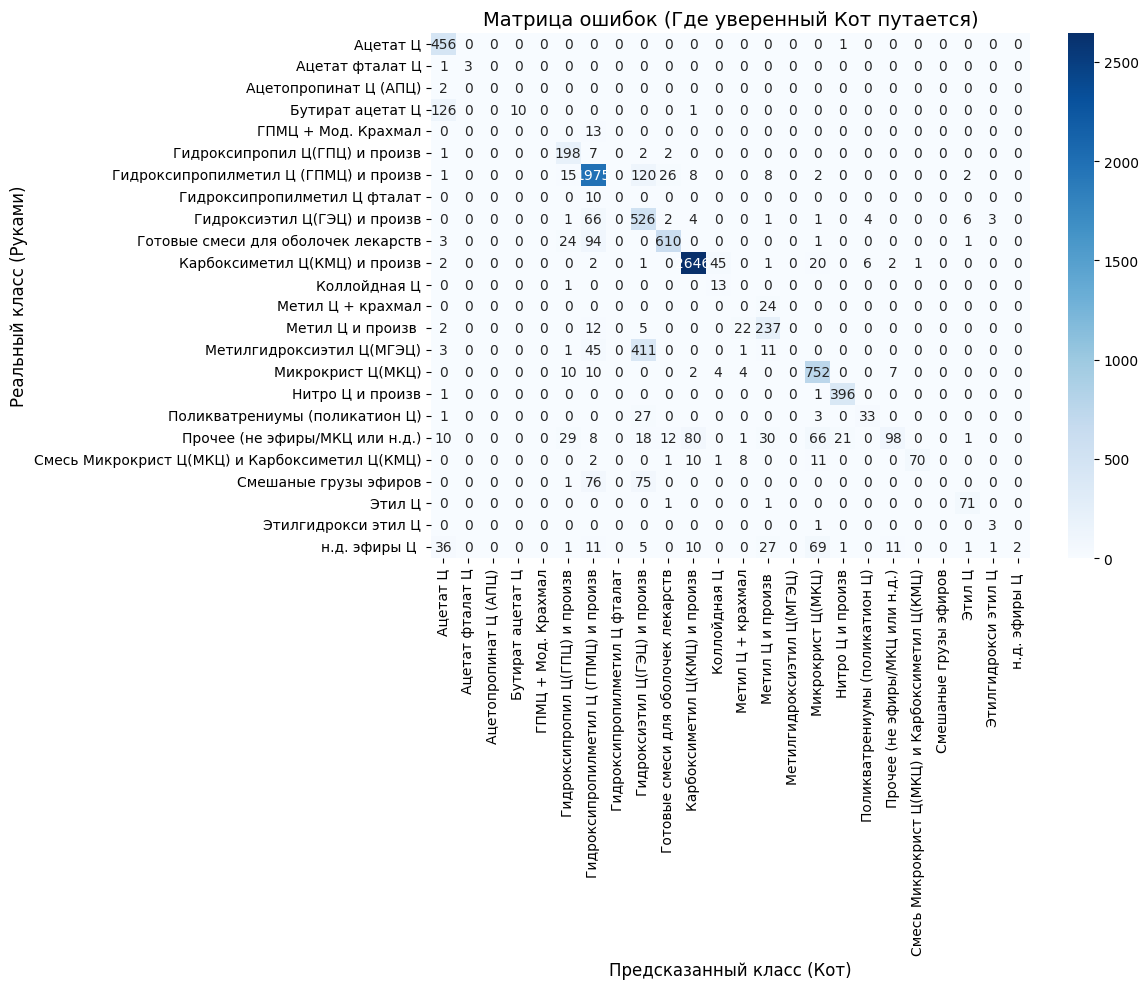


❌ Найдено расхождений среди уверенных ответов: 1884 из 9983
Примеры ошибок (Руками vs Кот):


,Полное описание,Реальность (Руками),Предсказание (Кот)
9,"""CELLULOSE ACETATE BUTYRATE"" (CAB-551-0.2) - П...",Бутират ацетат Ц,Ацетат Ц
24,"""HEADCEL M3225"" - ГИДРОКСИЭТИЛМЕТИЛЦЕЛЛЮЛОЗА В...",Метилгидроксиэтил Ц(МГЭЦ),Гидроксипропилметил Ц (ГПМЦ) и произв
25,"""HEADCEL M3225"" - ГИДРОКСИЭТИЛМЕТИЛЦЕЛЛЮЛОЗА В...",Метилгидроксиэтил Ц(МГЭЦ),Гидроксипропилметил Ц (ГПМЦ) и произв
26,"""HEADCEL M3225"" - ГИДРОКСИЭТИЛМЕТИЛЦЕЛЛЮЛОЗА В...",Метилгидроксиэтил Ц(МГЭЦ),Гидроксипропилметил Ц (ГПМЦ) и произв
36,"""MH-EM6020"" - ГИДРОКСИЭТИЛМЕТИЛЦЕЛЛЮЛОЗА В ПЕР...",Метилгидроксиэтил Ц(МГЭЦ),Гидроксипропилметил Ц (ГПМЦ) и произв
51,"""NORCELL HPMC MH-K200"" - ГИДРОКСИПРОПИЛМЕТИЛЦЕ...",Смешаные грузы эфиров,Гидроксипропилметил Ц (ГПМЦ) и произв
57,"""NORCELL MH-EM C9115"" - МЕТИЛГИДРОКСИЭТИЛЦЕЛЛЮ...",Смешаные грузы эфиров,Гидроксипропилметил Ц (ГПМЦ) и произв
59,"""OY-S-8761 (OPADRY ORANGE)"" - ГИДРОКСИПРОПИЛМЕ...",Готовые смеси для оболочек лекарств,Гидроксипропилметил Ц (ГПМЦ) и произв
60,"""OY-S-8761 (OPADRY ORANGE)"" - ГИДРОКСИПРОПИЛМЕ...",Готовые смеси для оболочек лекарств,Гидроксипропилметил Ц (ГПМЦ) и произв
61,"""OY-S-8761 (OPADRY ORANGE)"" - ГИДРОКСИПРОПИЛМЕ...",Готовые смеси для оболочек лекарств,Гидроксипропилметил Ц (ГПМЦ) и произв



💾 Полный список расхождений сохранен в файл: Анализ_ошибок_CatBoost_Уверенные.xlsx


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. ЗАГРУЖАЕМ ОБА ФАЙЛА
file_manual = 'Целлюлоза верификация.xlsx' # Твой файл со скрина
file_pred = 'Hybrid_Result_Cellulose.xlsx' # Файл с ответами Кота

df_true = pd.read_excel(file_manual)
df_pred = pd.read_excel(file_pred)

# 2. ФИЛЬТРУЕМ КОТА (Берем только те строки, где он уверен)
df_pred_confident = df_pred[df_pred['продукт единый'] != 'ТРЕБУЕТСЯ LLM'].copy()

print(f"Уверенных строк от Кота для проверки: {len(df_pred_confident)}")

# 3. УМНОЕ ОБЪЕДИНЕНИЕ (Аналог ВПР/VLOOKUP)
# pandas сам найдет совпадения текста, даже если строки перемешаны!
df_merged = pd.merge(
    df_true[['Полное описание', 'ПРОДУКТ ЕДИНЫЙ']], # Названия строго как на твоем скрине
    df_pred_confident[['Описание 350 крт', 'продукт единый']], 
    left_on='Полное описание', 
    right_on='Описание 350 крт', 
    how='inner' # Оставляем только те строки, которые нашлись в обоих файлах
)

df_merged = df_merged.rename(columns={
    'ПРОДУКТ ЕДИНЫЙ': 'Реальность (Руками)',
    'продукт единый': 'Предсказание (Кот)'
})

y_true = df_merged['Реальность (Руками)']
y_pred = df_merged['Предсказание (Кот)']

print(f"✅ Успешно сопоставлено строк (нашлось в обоих файлах): {len(df_merged)}")

# 4. ВЫВОДИМ БАЗОВЫЕ МЕТРИКИ ДЛЯ УВЕРЕННОГО КОТА
accuracy = accuracy_score(y_true, y_pred)
print(f"\n🎯 Точность уверенных ответов (Accuracy): {accuracy:.2%}")
print("-" * 60)
print("📊 ОТЧЕТ ПО КЛАССАМ (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred, zero_division=0)) 

# 5. РИСУЕМ МАТРИЦУ ОШИБОК
plt.figure(figsize=(12, 10))
labels = sorted(list(set(y_true) | set(y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Матрица ошибок (Где уверенный Кот путается)', fontsize=14)
plt.ylabel('Реальный класс (Руками)', fontsize=12)
plt.xlabel('Предсказанный класс (Кот)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 6. ВЫВОД И СОХРАНЕНИЕ ОШИБОК (Чтобы глазами посмотреть, где Кот соврал)
errors_df = df_merged[df_merged['Реальность (Руками)'] != df_merged['Предсказание (Кот)']].copy()

print(f"\n❌ Найдено расхождений среди уверенных ответов: {len(errors_df)} из {len(df_merged)}")
if len(errors_df) > 0:
    print("Примеры ошибок (Руками vs Кот):")
    display(errors_df[['Полное описание', 'Реальность (Руками)', 'Предсказание (Кот)']].head(15))
    
    error_file_path = 'Анализ_ошибок_CatBoost_Уверенные.xlsx'
    errors_df[['Полное описание', 'Реальность (Руками)', 'Предсказание (Кот)']].to_excel(error_file_path, index=False)
    print(f"\n💾 Полный список расхождений сохранен в файл: {error_file_path}")

In [15]:
# 1. Загружаем наш лучший файл и ручной эталон
df_final = pd.read_excel('Hybrid_Result_Cellulose.xlsx')
df_true = pd.read_excel('Целлюлоза верификация.xlsx')

# 2. ФУНКЦИЯ "ЧИТ-КОД" (Исправляет слепые зоны Кота)
def apply_cheat_codes(row):
    text = str(row['Описание 350 крт']).lower()
    current_cat = row['продукт единый']
    
    # Если это было отложено для LLM, пока не трогаем (или трогаем, как хочешь)
    if current_cat == "ТРЕБУЕТСЯ LLM":
        return current_cat
        
    # Спасаем МГЭЦ
    if "mhec" in text or "мгэц" in text or "метилгидроксиэтил" in text or "walocel" in text:
        return "Метилгидроксиэтил Ц(МГЭЦ)"
        
    # Спасаем Бутират
    if "бутират" in text or "cab" in text or "butyrate" in text:
        return "Бутират ацетат Ц"
        
    # Очищаем Прочее (Многие люди кидают в прочее то, что является ГПМЦ)
    if "hpmc" in text or "гипромеллоза" in text:
        # Но проверяем, не оболочка ли это
        if "оболоч" not in text and "opadry" not in text and "покрыти" not in text:
            return "Гидроксипропилметил Ц (ГПМЦ) и произв"

    return current_cat

print("Применяю химические чит-коды к предсказаниям...")
df_final['продукт единый'] = df_final.apply(apply_cheat_codes, axis=1)

# 3. ПЕРЕСЧИТЫВАЕМ ТОЧНОСТЬ УВЕРЕННЫХ ОТВЕТОВ
df_pred_confident = df_final[df_final['продукт единый'] != 'ТРЕБУЕТСЯ LLM'].copy()

df_merged = pd.merge(
    df_true[['Полное описание', 'ПРОДУКТ ЕДИНЫЙ']], 
    df_pred_confident[['Описание 350 крт', 'продукт единый']], 
    left_on='Полное описание', 
    right_on='Описание 350 крт', 
    how='inner' 
)

y_true = df_merged['ПРОДУКТ ЕДИНЫЙ']
y_pred = df_merged['продукт единый']

accuracy = accuracy_score(y_true, y_pred)
print(f"\n🔥 НОВАЯ ТОЧНОСТЬ (После чит-кодов): {accuracy:.2%}")

# Выводим только те классы, которые мы лечили, чтобы посмотреть разницу
print(classification_report(y_true, y_pred, zero_division=0, labels=['Метилгидроксиэтил Ц(МГЭЦ)', 'Бутират ацетат Ц', 'Гидроксипропилметил Ц (ГПМЦ) и произв']))

Применяю химические чит-коды к предсказаниям...

🔥 НОВАЯ ТОЧНОСТЬ (После чит-кодов): 85.59%
                                       precision    recall  f1-score   support

            Метилгидроксиэтил Ц(МГЭЦ)       0.63      0.84      0.72       472
                     Бутират ацетат Ц       0.97      1.00      0.99       137
Гидроксипропилметил Ц (ГПМЦ) и произв       0.87      0.91      0.89      2157

                            micro avg       0.82      0.90      0.86      2766
                            macro avg       0.82      0.92      0.86      2766
                         weighted avg       0.83      0.90      0.87      2766



## Добиваем фаил через LLM

In [25]:
# 1. ЗАГРУЖАЕМ ГИБРИДНЫЙ ФАЙЛ (после CatBoost)
file_path = 'Hybrid_Result_Cellulose.xlsx'
df = pd.read_excel(file_path)

text_col = 'Описание 350 крт'
target_col = 'продукт единый'

# Выделяем строки, которые нужно "добить" нейросетью
mask_llm = df[target_col] == "ТРЕБУЕТСЯ LLM"
df_to_process = df[mask_llm].copy()

total_to_process = len(df_to_process)
print(f"Найдено {total_to_process} строк для обработки через LLM...")

if total_to_process == 0:
    print("🎉 Все строки уже размечены! Финальная обработка не требуется.")
else:
    # 2. ФУНКЦИЯ ЗАПРОСА К LLM (используем ту же, что и раньше)
    SYSTEM_PROMPT = """Ты — ведущий химический аналитик. Твоя задача — классифицировать таможенные описания производных целлюлозы. Верни строго валидный JSON с 1 полем: "Продукт единый". Никакого лишнего текста.

ПРАВИЛО: Выбери СТРОГО ОДНО значение из списка категорий ниже (копируй символ в символ, буква 'Ц' означает Целлюлоза). Если сомневаешься или продукта нет в списке, пиши "Прочее (не эфиры/МКЦ или н.д.)".

РАЗРЕШЕННЫЙ СПИСОК КАТЕГОРИЙ:
- Ацетат фталат Ц
- Ацетат Ц
- Ацетопропинат Ц (АПЦ)
- Бутират ацетат Ц
- Гидроксипропил Ц(ГПЦ) и произв
- Гидроксипропилметил Ц (ГПМЦ) и произв
- Гидроксипропилметил Ц фталат
- Гидроксиэтил Ц(ГЭЦ) и произв
- Готовые смеси для оболочек лекарств
- ГПМЦ + Мод. Крахмал
- Диэтиламиноэтил Ц (DEAE)
- Карбоксиметил Ц(КМЦ) и произв
- Коллойдная Ц
- Метил Ц + крахмал
- Метил Ц и произв 
- Метилгидроксиэтил Ц(МГЭЦ)
- Микрокрист Ц(МКЦ)
- н.д. эфиры Ц 
- Нитро Ц и произв
- Поликватрениумы (поликатион Ц)
- Прочее (не эфиры/МКЦ или н.д.)
- Смесь Микрокрист Ц(МКЦ) и Карбоксиметил Ц(КМЦ)
- Смешаные грузы эфиров
- Триацетат Ц
- Этил Ц
- Этилгидрокси этил Ц"""

    def ask_qwen(text):
        if pd.isna(text) or str(text).strip() == "": return "Пусто"
        url = "http://127.0.0.1:1234/v1/chat/completions"
        payload = {
            "model": "qwen2.5-7b-instruct",
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": f"Вход: {text}"}
            ],
            "temperature": 0.0
        }
        try:
            response = requests.post(url, json=payload, timeout=60)
            result_text = response.json()['choices'][0]['message']['content']
            clean_json = re.search(r'\{.*\}', result_text, re.DOTALL)
            parsed = json.loads(clean_json.group(0)) if clean_json else json.loads(result_text)
            return parsed.get("Продукт единый", "Ошибка формата")
        except Exception:
            return "Ошибка API"

    # 3. ФУНКЦИЯ-САНИТАР (чтобы сразу чистить ответы)
    def fix_qwen_errors_lite(val_str):
        if pd.isna(val_str): return "Прочее (не эфиры/МКЦ или н.д.)"
        val_lower = str(val_str).strip().lower()
        if "ошибка" in val_lower or "пусто" in val_lower: return "Прочее (не эфиры/МКЦ или н.д.)"
        if "мкц" in val_lower and "кмц" in val_lower: return "Смесь Микрокрист Ц(МКЦ) и Карбоксиметил Ц(КМЦ)"
        if "гпмц" in val_lower and "крахмал" in val_lower: return "ГПМЦ + Мод. Крахмал"
        if "метил" in val_lower and "крахмал" in val_lower: return "Метил Ц + крахмал"
        if "карбоксиметил" in val_lower or "кмц" in val_lower or "cmc" in val_lower: return "Карбоксиметил Ц(КМЦ) и произв"
        if "гидроксипропилметил" in val_lower or "гпмц" in val_lower or "hpmc" in val_lower: return "Гидроксипропилметил Ц (ГПМЦ) и произв"
        if "гидроксиэтил" in val_lower or "гэц" in val_lower or "hec" in val_lower: return "Гидроксиэтил Ц(ГЭЦ) и произв"
        if "микрокрист" in val_lower or "мкц" in val_lower or "mcc" in val_lower: return "Микрокрист Ц(МКЦ)"
        if "готовые смеси" in val_lower or "оболоч" in val_lower: return "Готовые смеси для оболочек лекарств"
        return str(val_str).strip() # Возвращаем как есть, если не попало в частые ошибки

    # 4. ЗАПУСКАЕМ ОБРАБОТКУ С БЭКАПАМИ
    indices = df_to_process.index.tolist()
    
    for i, idx in enumerate(tqdm(indices, desc="Добиваем остатки LLM")):
        text = df.at[idx, text_col]
        
        # Спрашиваем нейросеть
        raw_result = ask_qwen(text)
        
        # Сразу чистим санитаром
        clean_result = fix_qwen_errors_lite(raw_result)
        
        # Записываем в основной датафрейм
        df.at[idx, target_col] = clean_result
        
        # Бэкап каждые 50 строк
        if (i + 1) % 50 == 0:
            df.to_excel('backup_final_processing.xlsx', index=False)
            tqdm.write(f"💾 Бэкап: обработано {i + 1} из {total_to_process}.")

    # 5. СОХРАНЯЕМ ИТОГОВЫЙ ФАЙЛ
    output_final = 'FINAL_Dataset_Cellulose_100_percent.xlsx'
    
    # Оставляем только нужные колонки, если их было больше
    df_final = df[[text_col, target_col]]
    df_final.to_excel(output_final, index=False)

    print("\n" + "🔥"*25)
    print(f"ВСЁ ГОТОВО! Пайплайн успешно завершен.")
    print(f"Полностью размеченный файл сохранен: {output_final}")
    print("🔥"*25)
    
    # Показываем финальную статистику
    print("\nИтоговое распределение по всем строкам:")
    display(df_final[target_col].value_counts())

📝 ТЕКСТ ДЛЯ АНАЛИЗА:
Было

⏳ Отправляю запрос к Qwen...
🌐 СТАТУС СЕРВЕРА: 200
🤖 СЫРОЙ ОТВЕТ ИИ:
```json
{
    "Продукт единый": "Было"
}
```

✅ УСПЕШНО РАСПАРСЕНО: {'Продукт единый': 'Было'}


## Считаем точность 

In [ ]:
# 1. ЗАГРУЖАЕМ ОБА ФАЙЛА
file_manual = 'Целлюлоза верификация.xlsx' # Ручной эталон
file_pred = 'FINAL_Dataset_Cellulose_100_percent.xlsx' # Наш сгенерированный файл

df_true = pd.read_excel(file_manual)
df_pred = pd.read_excel(file_pred)

# 2. ОБЪЕДИНЯЕМ ТАБЛИЦЫ ДЛЯ СРАВНЕНИЯ
# Поскольку названия столбцов с текстом могут немного отличаться, клеим аккуратно:
# В ручном файле текст в 'Полное описание', в нашем — 'Описание 350 крт'
df_merged = pd.merge(
    df_true[['Полное описание', 'Продукт единый']], 
    df_pred[['Описание 350 крт', 'продукт единый']], 
    left_on='Полное описание', 
    right_on='Описание 350 крт', 
    how='inner' # Берем только те строки, которые есть в обоих файлах
)

# Переименуем колонки для удобства
df_merged = df_merged.rename(columns={
    'Продукт единый': 'Реальность (Руками)',
    'продукт единый': 'Предсказание (Пайплайн)'
})

y_true = df_merged['Реальность (Руками)']
y_pred = df_merged['Предсказание (Пайплайн)']

print(f"Успешно сопоставлено строк для проверки: {len(df_merged)}")

# 3. ВЫВОДИМ БАЗОВЫЕ МЕТРИКИ
accuracy = accuracy_score(y_true, y_pred)
print(f"\n🎯 Общая точность (Accuracy): {accuracy:.2%}")
print("-" * 60)
print("📊 ОТЧЕТ ПО КЛАССАМ (Precision, Recall, F1-Score):")
# zero_division=0 скрывает предупреждения, если модель вообще не предсказала какой-то редкий класс
print(classification_report(y_true, y_pred, zero_division=0)) 

# 4. РИСУЕМ МАТРИЦУ ОШИБОК (КРАСИВЫЙ ГРАФИК)
# Это покажет, какие классы путаются между собой
plt.figure(figsize=(12, 10))
labels = sorted(list(set(y_true) | set(y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Матрица ошибок (Где путается модель)', fontsize=14)
plt.ylabel('Реальный класс (Руками)', fontsize=12)
plt.xlabel('Предсказанный класс (Пайплайн)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 5. ВЫВОДИМ ТОП ОШИБОК ДЛЯ ГЛАЗНОГО АНАЛИЗА И СОХРАНЯЕМ В EXCEL
# Отфильтруем строки, где модель ошиблась
errors_df = df_merged[df_merged['Реальность (Руками)'] != df_merged['Предсказание (Пайплайн)']].copy()

print(f"\n❌ Найдено расхождений: {len(errors_df)} из {len(df_merged)}")
if len(errors_df) > 0:
    print("Примеры ошибок (что было на самом деле vs что решила модель):")
    # Выводим первые 15 ошибок на экран
    display(errors_df[['Полное описание', 'Реальность (Руками)', 'Предсказание (Пайплайн)']].head(15))
    
    # СОХРАНЯЕМ ВЕСЬ СПИСОК ОШИБОК В ФАЙЛ
    error_file_path = 'Анализ_ошибок_Целлюлоза.xlsx'
    errors_df[['Полное описание', 'Реальность (Руками)', 'Предсказание (Пайплайн)']].to_excel(error_file_path, index=False)
    print(f"\n💾 Полный список расхождений сохранен в файл для ручного разбора: {error_file_path}")

## 📊 Визуализация и анализ результатов
После завершения обработки мы можем проанализировать распределение категорий и эффективность гибридного подхода.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Установка стиля для презентабельного вида
sns.set_theme(style="whitegrid", palette="pastel")
plt.rcParams['figure.figsize'] = [12, 7]
plt.rcParams['font.size'] = 12

def plot_analysis(df_final, catboost_count, llm_count):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))
    
    # 1. Круговая диаграмма эффективности методов
    labels = ['CatBoost (Быстро)', 'LLM (Глубоко)']
    sizes = [catboost_count, llm_count]
    explode = (0.1, 0) 
    
    ax1.pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', 
            shadow=True, startangle=140, colors=['#4CAF50', '#2196F3'])
    ax1.set_title('Эффективность гибридного подхода', fontsize=16, fontweight='bold')
    
    # 2. Распределение по категориям
    category_counts = df_final['Продукт единый'].value_counts().head(15)
    sns.barplot(x=category_counts.values, y=category_counts.index, ax=ax2, palette='magma')
    ax2.set_title('Топ-15 категорий товаров', fontsize=16, fontweight='bold')
    ax2.set_xlabel('Количество товаров')
    ax2.set_ylabel('')
    
    plt.tight_layout()
    plt.show()

# Пример вызова (замените переменные на реальные после выполнения ячеек):
# plot_analysis(df_result, catboost_success, need_llm)

# Целлюлоза С контекстом


## Создаём промпт

## Снова размечаем

In [18]:
# =====================================================================
# 1. ЗАГРУЖАЕМ ЗОЛОТОЙ СТАНДАРТ И ГЕНЕРИРУЕМ ПРИМЕРЫ ДЛЯ ПРОМПТА
# =====================================================================
gold_path = 'Произв Целл для проверки Accuracy.xlsx'
df_gold = pd.read_excel(gold_path, sheet_name='Выборка в работу (размеченная)')

# Фильтруем строки с пометкой "Да" в колонке для контекста
mask_context = df_gold['Берём для контекста?'].astype(str).str.contains('Да', case=False, na=False)
df_examples = df_gold[mask_context].head(15)

dynamic_examples = ""
for i, (_, row) in enumerate(df_examples.iterrows(), 1):
    desc = str(row['Описание 350']).replace('\n', ' ')
    cat = str(row['ПРОДУКТ ЕДИНЫЙ'])
    dynamic_examples += f"ПРИМЕР {i}:\nВход: \"{desc}\"\nВыход: {{\n  \"Продукт единый\": \"{cat}\"\n}}\n\n"

print(f"✅ Извлечено {len(df_examples)} сложных примеров из золотого стандарта для обучения нейросети.")

# =====================================================================
# 2. ИДЕАЛЬНЫЙ МЕГА-ПРОМПТ (Правила + Динамические примеры)
# =====================================================================
SYSTEM_PROMPT_V2 = f"""Ты — ведущий химический аналитик. Твоя задача — классифицировать таможенные описания производных целлюлозы. Верни строго валидный JSON с 1 полем: "Продукт единый". Никакого лишнего текста.

ПРАВИЛО: Выбери СТРОГО ОДНО значение из списка категорий ниже. Если сомневаешься, пиши "Прочее (не эфиры/МКЦ или н.д.)".

РАЗРЕШЕННЫЙ СПИСОК КАТЕГОРИЙ:
- Ацетат фталат Ц
- Ацетат Ц
- Ацетопропинат Ц (АПЦ)
- Бутират ацетат Ц
- Гидроксипропил Ц(ГПЦ) и произв
- Гидроксипропилметил Ц (ГПМЦ) и произв
- Гидроксипропилметил Ц фталат
- Гидроксиэтил Ц(ГЭЦ) и произв
- Готовые смеси для оболочек лекарств
- ГПМЦ + Мод. Крахмал
- Диэтиламиноэтил Ц (DEAE)
- Карбоксиметил Ц(КМЦ) и произв
- Коллойдная Ц
- Метил Ц + крахмал
- Метил Ц и произв 
- Метилгидроксиэтил Ц(МГЭЦ)
- Микрокрист Ц(МКЦ)
- н.д. эфиры Ц 
- Нитро Ц и произв
- Поликватрениумы (поликатион Ц)
- Прочее (не эфиры/МКЦ или н.д.)
- Смесь Микрокрист Ц(МКЦ) и Карбоксиметил Ц(КМЦ)
- Смешаные грузы эфиров
- Триацетат Ц
- Этил Ц
- Этилгидрокси этил Ц

ЖЕСТКИЕ ПОДСКАЗКИ ДЛЯ КЛАССИФИКАЦИИ (ЧИТАЙ ВНИМАТЕЛЬНО!):
- ❗️ Если в тексте есть "Opadry", "Aquapolish", "Colorcon", "пленочное покрытие", "оболочка" — это СТРОГО "Готовые смеси для оболочек лекарств", ДАЖЕ ЕСЛИ в составе указан ГПМЦ или HPMC!
- ❗️ Строго различай HPMC (ГПМЦ) и MHEC (МГЭЦ)! Если видишь "MHEC", "Метилгидроксиэтил", "WALOCEL" — это СТРОГО "Метилгидроксиэтил Ц(МГЭЦ)". Не путай с ГПМЦ!
- "Кроскармеллоза", "CMC", "Карбоксиметил", "BLANOSE" -> "Карбоксиметил Ц(КМЦ) и произв"
- "HPMC", "Гипромеллоза", "METOLOSE", "METHOCEL" -> "Гидроксипропилметил Ц (ГПМЦ) и произв" (но если это оболочка, см. правило выше!)
- "HEC", "Гидроксиэтилцеллюлоза", "NATROSOL", "CELLOSIZE", "Tylose" -> "Гидроксиэтил Ц(ГЭЦ) и произв"
- "Polyquaternium", "ПОЛИКВАТЕРНИУМ", "DEKAQUAT" -> "Поликватрениумы (поликатион Ц)"
- "Klucel", "HPC", "Гидроксипропилцеллюлоза" -> "Гидроксипропил Ц(ГПЦ) и произв"
- "Фильтры", "сигарет" -> "Ацетат Ц"

ПРИМЕРЫ ДЛЯ КОНТЕКСТА:
{dynamic_examples}
"""

# =====================================================================
# 3. ЗАГРУЖАЕМ ИСХОДНЫЕ ДАННЫЕ ДЛЯ РАЗМЕТКИ
# =====================================================================
file_path = 'data.xlsx'
df = pd.read_excel(file_path)

column_to_analyze = 'Описание 350 крт'

# Выбираем 2000 случайных строк
sample_size = min(2000, len(df))
df_sample = df.sample(n=sample_size, random_state=42).copy()
df_sample['продукт единый'] = None

# =====================================================================
# 4. ФУНКЦИЯ ОБРАЩЕНИЯ К LLM
# =====================================================================
def ask_qwen(text):
    if pd.isna(text) or text == "":
        return "Пусто"
    
    url = "http://127.0.0.1:1234/v1/chat/completions"
    
    payload = {
        "model": "qwen2.5-7b-instruct",
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT_V2}, # ИСПОЛЬЗУЕМ НОВЫЙ ПРОМПТ!
            {"role": "user", "content": f"Вход: {text}"}
        ],
        "temperature": 0.0
    }
    
    for attempt in range(3):
        try:
            response = requests.post(url, json=payload, timeout=60)
            result_text = response.json()['choices'][0]['message']['content']
            
            clean_json = re.search(r'\{.*\}', result_text, re.DOTALL)
            if clean_json:
                parsed = json.loads(clean_json.group(0))
            else:
                parsed = json.loads(result_text)
                
            return parsed.get("Продукт единый", "Ошибка формата")
                
        except Exception as e:
            if attempt == 2: 
                return "Ошибка API"
            time.sleep(2)

# =====================================================================
# 5. ЦИКЛ ОБРАБОТКИ И СОХРАНЕНИЯ
# =====================================================================
print(f"Запускаю анализ {sample_size} строк. Бэкап будет сохраняться каждые 100 строк...")

indices = df_sample.index.tolist()

for i, idx in enumerate(tqdm(indices, desc="Прогресс обработки")):
    text = df_sample.at[idx, column_to_analyze]
    
    result = ask_qwen(text)
    df_sample.at[idx, 'продукт единый'] = result
    
    # Делаем бэкап с новым именем
    if (i + 1) % 100 == 0:
        backup_df = df_sample[[column_to_analyze, 'продукт единый']]
        backup_df.to_excel('backup_checkpoint_few_shot.xlsx', index=False)
        tqdm.write(f"💾 Сохранен бэкап: обработано {i + 1} из {sample_size} строк.")

# Сохраняем финальный результат в новый файл
df_final = df_sample[[column_to_analyze, 'продукт единый']]
output_file = 'training_sample_2000_few_shot.xlsx'
df_final.to_excel(output_file, index=False)

print(f"\n🎉 Готово! Финальный результат сохранен в НОВЫЙ файл: {output_file}")
display(df_final.head(10))

✅ Извлечено 15 сложных примеров из золотого стандарта для обучения нейросети.
Запускаю анализ 2000 строк. Бэкап будет сохраняться каждые 100 строк...


Прогресс обработки:   5%|██▉                                                        | 100/2000 [01:56<36:43,  1.16s/it]

💾 Сохранен бэкап: обработано 100 из 2000 строк.


Прогресс обработки:  10%|█████▉                                                     | 200/2000 [03:44<36:06,  1.20s/it]

💾 Сохранен бэкап: обработано 200 из 2000 строк.


...

Прогресс обработки:  95%|███████████████████████████████████████████████████████   | 1900/2000 [33:13<02:41,  1.62s/it]

💾 Сохранен бэкап: обработано 1900 из 2000 строк.


Прогресс обработки: 100%|██████████████████████████████████████████████████████████| 2000/2000 [35:02<00:00,  1.05s/it]


💾 Сохранен бэкап: обработано 2000 из 2000 строк.

🎉 Готово! Финальный результат сохранен в НОВЫЙ файл: training_sample_2000_few_shot.xlsx


,Описание 350 крт,продукт единый
169,"""TYLOSE HX 6000 YG4""-ГИДРОФОБНО-МОДИФИЦИРОВАНН...",Гидроксиэтил Ц(ГЭЦ) и произв
8875,НИТРОЦЕЛЛЮЛОЗА РАСТВОРЕНАЯ В 30% ИЗОПРОПИЛОВОМ...,Нитро Ц и произв
16789,ЭФИРЫ ЦЕЛЛЮЛОЗЫ ПРОСТЫЕ:МЕТОЦЕЛ К15М PREMIUM Г...,Гидроксипропилметил Ц (ГПМЦ) и произв
2267,БУТИРАТ АЦЕТАТА ЦЕЛЛЮЛОЗЫ. CAS 9004-36-8=ЭФИР...,Ацетат Ц
15927,"ЭФИРЫ ЦЕЛЛЮЛОЗЫ ПРОСТЫЕ, НЕ ПРЕДНАЗНАЧЕНЫ ДЛЯ ...",н.д. эфиры Ц
9304,ПИЩЕВАЯ ДОБАВКА - КАРБОКСИМЕТИЛЦЕЛЛЮЛОЗЫ НАТРИ...,Карбоксиметил Ц(КМЦ) и произв
828,E461 МЕТИЛЦЕЛЛЮЛОЗА (METILCELLULOSA) - ЭФИР МЕ...,Метил Ц и произв
7975,НАТРИЕВАЯ КАРБОМЕТИЛЦЕЛЛЮЛОЗА (КМЦ)(НАТРИЕВАЯ ...,Карбоксиметил Ц(КМЦ) и произв
15088,ЭФИРЫ ЦЕЛЛЮЛОЗЫ ПРОСТЫЕ В ПЕРВИЧНОЙ ФОРМЕ (ПОР...,Метилгидроксиэтил Ц(МГЭЦ)
14789,ЭФИРЫ ЦЕЛЛЮЛОЗЫ ПРОСТЫЕ - ВОДОРАСТВОРИМАЯ ГИДР...,Гидроксиэтил Ц(ГЭЦ) и произв


## Чиним категории

In [19]:
import pandas as pd

# Загружаем наш НОВЫЙ файл после обработки нейросетью с примерами
file_path = 'training_sample_2000_few_shot.xlsx'
df = pd.read_excel(file_path)

target_col = 'продукт единый'

def fix_qwen_errors(val):
    if pd.isna(val): 
        return "Прочее (не эфиры/МКЦ или н.д.)"
    
    val_str = str(val).strip()
    val_lower = val_str.lower()
    
    if "ошибка" in val_lower or "пусто" in val_lower or "error" in val_lower:
        return "Прочее (не эфиры/МКЦ или н.д.)"

    # 1. ОБНОВЛЕННЫЙ ЖЕСТКИЙ СЛОВАРЬ (С учетом новых фантазий LLM)
    exact_mapping = {
        "ацетат бутират ц": "Бутират ацетат Ц",
        "ацетобутират ц": "Бутират ацетат Ц",
        "бутират ц": "Бутират ацетат Ц",
        "бутират целлюлозы": "Бутират ацетат Ц",
        "бутират целлюлозы cab381": "Бутират ацетат Ц",
        "коллоидная ц": "Коллойдная Ц",
        "метил гидроксипропил целлюлоза": "Гидроксипропилметил Ц (ГПМЦ) и произв",
        "метил гидроксиэтил ц(мгэц)": "Метилгидроксиэтил Ц(МГЭЦ)",
        "метил гидроксиэтил ц(мгэц) и произв": "Метилгидроксиэтил Ц(МГЭЦ)",
        "метилгидроксиэтил ц(мгэц) и произв": "Метилгидроксиэтил Ц(МГЭЦ)",
        "микрокрист ц(мкц) и произв": "Микрокрист Ц(МКЦ)",
        "н.д.": "н.д. эфиры Ц ", 
        "н.д. эфиры ц": "н.д. эфиры Ц ", 
        "эфиры целлюлозы": "н.д. эфиры Ц ",
        "нитрат ц и произв": "Нитро Ц и произв",
        "нитраты целлюлозы": "Нитро Ц и произв",
        "этилгидроксиэтил ц": "Этилгидрокси этил Ц",
        "этиловый эфир целлюлозы": "Этил Ц",
        "целлюлоза": "Прочее (не эфиры/МКЦ или н.д.)",
        "полиакрилонатная целлюлоза": "Прочее (не эфиры/МКЦ или н.д.)"
    }
    
    if val_lower in exact_mapping:
        return exact_mapping[val_lower]

    # 2. ПОИСК ПО ПОДСТРОКАМ (Оставляем как предохранитель)
    if "мкц" in val_lower and "кмц" in val_lower: return "Смесь Микрокрист Ц(МКЦ) и Карбоксиметил Ц(КМЦ)"
    if "гпмц" in val_lower and "крахмал" in val_lower: return "ГПМЦ + Мод. Крахмал"
    if "метил" in val_lower and "крахмал" in val_lower: return "Метил Ц + крахмал"
    if "ацетат" in val_lower and "фталат" in val_lower: return "Ацетат фталат Ц"
    if "бутират" in val_lower and "ацетат" in val_lower: return "Бутират ацетат Ц"
    if "гидроксипропилметил" in val_lower and "фталат" in val_lower: return "Гидроксипропилметил Ц фталат"
    if "карбоксиметил" in val_lower or "кмц" in val_lower or "cmc" in val_lower: return "Карбоксиметил Ц(КМЦ) и произв"
    if "гидроксипропилметил" in val_lower or "гпмц" in val_lower or "hpmc" in val_lower: return "Гидроксипропилметил Ц (ГПМЦ) и произв"
    if "гидроксиэтил" in val_lower or "гэц" in val_lower or "hec" in val_lower: return "Гидроксиэтил Ц(ГЭЦ) и произв"
    if "метилгидроксиэтил" in val_lower or "мгэц" in val_lower: return "Метилгидроксиэтил Ц(МГЭЦ)"
    if "этилгидрокси" in val_lower: return "Этилгидрокси этил Ц"
    if "гидроксипропил" in val_lower or "гпц" in val_lower: return "Гидроксипропил Ц(ГПЦ) и произв"
    if "микрокрист" in val_lower or "мкц" in val_lower or "mcc" in val_lower: return "Микрокрист Ц(МКЦ)"
    if "поликватерниум" in val_lower or "поликатион" in val_lower or "polyquaternium" in val_lower: return "Поликватрениумы (поликатион Ц)"
    if "готовые смеси" in val_lower or "оболоч" in val_lower or "пленочн" in val_lower: return "Готовые смеси для оболочек лекарств"
    if "ацетопропи" in val_lower or "апц" in val_lower: return "Ацетопропинат Ц (АПЦ)"
    if "диэтиламиноэтил" in val_lower or "deae" in val_lower: return "Диэтиламиноэтил Ц (DEAE)"
    if "нитро" in val_lower or "нитрат" in val_lower: return "Нитро Ц и произв"
    if "триацетат" in val_lower: return "Триацетат Ц"
    if "этил" in val_lower and "гидрокси" not in val_lower: return "Этил Ц"
    if "метил" in val_lower and "гидрокси" not in val_lower: return "Метил Ц и произв "
    if "ацетат" in val_lower and "фталат" not in val_lower and "бутират" not in val_lower: return "Ацетат Ц"
    if "коллоид" in val_lower or "коллойд" in val_lower: return "Коллойдная Ц"
    if "смешан" in val_lower and "груз" in val_lower: return "Смешаные грузы эфиров"
    if "н.д." in val_lower or "эфиры целлюлозы" in val_lower: return "н.д. эфиры Ц "
    
    # 3. ФИНАЛЬНЫЙ ФИЛЬТР: Эталонные 26 категорий
    allowed_categories = [
        "Ацетат фталат Ц", "Ацетат Ц", "Ацетопропинат Ц (АПЦ)", "Бутират ацетат Ц",
        "Гидроксипропил Ц(ГПЦ) и произв", "Гидроксипропилметил Ц (ГПМЦ) и произв",
        "Гидроксипропилметил Ц фталат", "Гидроксиэтил Ц(ГЭЦ) и произв",
        "Готовые смеси для оболочек лекарств", "ГПМЦ + Мод. Крахмал",
        "Диэтиламиноэтил Ц (DEAE)", "Карбоксиметил Ц(КМЦ) и произв",
        "Коллойдная Ц", "Метил Ц + крахмал", "Метил Ц и произв ", 
        "Метилгидроксиэтил Ц(МГЭЦ)", "Микрокрист Ц(МКЦ)", "н.д. эфиры Ц ", 
        "Нитро Ц и произв", "Поликватрениумы (поликатион Ц)",
        "Прочее (не эфиры/МКЦ или н.д.)", "Смесь Микрокрист Ц(МКЦ) и Карбоксиметил Ц(КМЦ)",
        "Смешаные грузы эфиров", "Триацетат Ц", "Этил Ц", "Этилгидрокси этил Ц"
    ]
    
    val_cleaned = val_str.strip()
    for cat in allowed_categories:
        if val_cleaned == cat.strip():
            return cat
            
    return "Прочее (не эфиры/МКЦ или н.д.)"

print("Начинаю стандартизацию и лечение категорий...")

# Применяем функцию
df[target_col] = df[target_col].apply(fix_qwen_errors)

# Перезаписываем наш эталонный файл
df.to_excel(file_path, index=False)
print("ИДЕАЛЬНО! Файл вылечен и готов к подаче в CatBoost.")

# Выведем статистику
print("\nСтатистика по классам:")
display(df[target_col].value_counts())

Начинаю стандартизацию и лечение категорий...
ИДЕАЛЬНО! Файл вылечен и готов к подаче в CatBoost.

Статистика по классам:


продукт единый
Гидроксипропилметил Ц (ГПМЦ) и произв    437
Карбоксиметил Ц(КМЦ) и произв            423
н.д. эфиры Ц                             221
Микрокрист Ц(МКЦ)                        217
Гидроксиэтил Ц(ГЭЦ) и произв             189
Готовые смеси для оболочек лекарств      137
Ацетат Ц                                  76
Гидроксипропил Ц(ГПЦ) и произв            69
Метил Ц и произв                          61
Нитро Ц и произв                          60
Метил Ц + крахмал                         27
Поликватрениумы (поликатион Ц)            21
Метилгидроксиэтил Ц(МГЭЦ)                 19
Этил Ц                                    19
Бутират ацетат Ц                          11
Коллойдная Ц                               9
Ацетат фталат Ц                            3
Этилгидрокси этил Ц                        1
Name: count, dtype: int64

## Склеиваем обуч выборку с эталоном и учим кота 

In [22]:
import pandas as pd
import numpy as np
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# =====================================================================
# 1. ЗАГРУЖАЕМ ДАННЫЕ И СОЗДАЕМ МЕГА-ВЫБОРКУ ДЛЯ КОТА
# =====================================================================
file_path_full = 'data.xlsx' 
file_path_teacher = 'training_sample_2000_few_shot.xlsx' # Файл от Qwen
gold_path = 'Произв Целл для проверки Accuracy.xlsx'

df_full = pd.read_excel(file_path_full)
df_teacher = pd.read_excel(file_path_teacher)
df_gold = pd.read_excel(gold_path, sheet_name='Выборка в работу (размеченная)')

# ❗️ ФИЛЬТРУЕМ ЗОЛОТОЙ СТАНДАРТ (Берем только "Да, эксперимент 1")
mask_exp1 = df_gold['Берём для контекста?'].astype(str).str.strip() == 'Да, эксперимент 1'
df_gold_filtered = df_gold[mask_exp1].copy()

# Приводим отфильтрованный ручной файл к нашему стандарту
df_gold_clean = df_gold_filtered[['Описание 350', 'ПРОДУКТ ЕДИНЫЙ']].copy()
df_gold_clean = df_gold_clean.rename(columns={
    'Описание 350': 'Описание 350 крт',
    'ПРОДУКТ ЕДИНЫЙ': 'продукт единый'
})

# Склеиваем Qwen и отфильтрованный Золотой стандарт!
df_mega_train = pd.concat([df_teacher, df_gold_clean], ignore_index=True)

# Очищаем от пустых и дубликатов
df_mega_train = df_mega_train.dropna(subset=['Описание 350 крт', 'продукт единый'])
df_mega_train = df_mega_train.drop_duplicates(subset=['Описание 350 крт'])

print(f"Размер синтетической выборки (Qwen): {len(df_teacher)}")
print(f"Добавлено строк из Золотого Стандарта ('Да, эксперимент 1'): {len(df_gold_clean)}")
print(f"🔥 Итоговый размер МЕГА-выборки для обучения Кота: {len(df_mega_train)} уникальных строк\n")

# =====================================================================
# 2. ОЦЕНКА ТОЧНОСТИ КОТА (Внутренняя проверка)
# =====================================================================
text_col = 'Описание 350 крт'
target_col = 'продукт единый'

X = df_mega_train[[text_col]].astype(str)
y = df_mega_train[target_col]

X_train_split, X_test_split, y_train_split, y_test_split = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Оцениваю точность модели на отложенной выборке (20%)... (Ждем логи 👇)")
eval_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    text_features=[text_col],
    random_seed=42,
    auto_class_weights='Balanced', 
    thread_count=-1,
    verbose=0 # Отключил вывод каждого шага, чтобы не засорять экран
)

eval_model.fit(X_train_split, y_train_split)
preds_test = eval_model.predict(X_test_split)
acc = accuracy_score(y_test_split, preds_test)
print(f"🎯 Внутренняя точность CatBoost на МЕГА-выборке: {acc:.2%}\n")

# =====================================================================
# 3. ФИНАЛЬНОЕ ОБУЧЕНИЕ И РАЗМЕТКА ОСТАТКОВ
# =====================================================================
print("Быстро обучаю финальную модель на ВСЕХ размеченных строках...")
model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    text_features=[text_col],
    random_seed=42,
    auto_class_weights='Balanced', 
    thread_count=-1,
    verbose=0
)
model.fit(X.astype(str), y)

# Берем те строки из полного файла, которых еще нет в МЕГА-трейне
known_texts = df_mega_train[text_col].unique()
df_predict = df_full[~df_full[text_col].isin(known_texts)].copy()

X_unseen = df_predict[[text_col]].astype(str)
print(f"Приступаю к разметке {len(X_unseen)} новых строк...")

preds_classes = model.predict(X_unseen)
preds_proba = model.predict_proba(X_unseen)
max_probas = np.max(preds_proba, axis=1)

# =====================================================================
# 4. ЛОГИКА ДОВЕРИЯ (ПОРОГ 70%) И ВСТРОЕННЫЕ ЧИТ-КОДЫ
# =====================================================================
CONFIDENCE_THRESHOLD = 0.70

final_predictions = []
catboost_success = 0
need_llm = 0

for i in range(len(preds_classes)):
    text = str(X_unseen.iloc[i][text_col]).lower()
    
    # 1. Ответ от Кота
    if max_probas[i] >= CONFIDENCE_THRESHOLD:
        pred_class = preds_classes[i][0]
    else:
        pred_class = "ТРЕБУЕТСЯ LLM"
        
    # 2. ПЕРЕХВАТЧИК (ЧИТ-КОДЫ: переопределяем класс, если есть маркер)
    if "mhec" in text or "мгэц" in text or "метилгидроксиэтил" in text or "walocel" in text:
        pred_class = "Метилгидроксиэтил Ц(МГЭЦ)"
    elif "бутират" in text or "cab" in text or "butyrate" in text:
        pred_class = "Бутират ацетат Ц"
    elif "hpmc" in text or "гипромеллоза" in text:
        if "оболоч" not in text and "opadry" not in text and "покрыти" not in text:
            pred_class = "Гидроксипропилметил Ц (ГПМЦ) и произв"

    # 3. Статистика
    if pred_class == "ТРЕБУЕТСЯ LLM":
        need_llm += 1
    else:
        catboost_success += 1
        
    final_predictions.append(pred_class)

df_predict[target_col] = final_predictions

# =====================================================================
# 5. СКЛЕИВАЕМ ВСЁ В ОДИН ФАЙЛ
# =====================================================================
df_result = pd.concat([df_mega_train, df_predict], ignore_index=True)

output_path = 'Hybrid_Result_Cellulose_MEGA_exp1.xlsx'
df_result.to_excel(output_path, index=False)

print("\n" + "="*50)
print(f"🎉 ГОТОВО! Файл сохранен: {output_path}")
print(f"⚡ Размечено моментально (CatBoost + Чит-коды): {catboost_success} строк")
print(f"🧠 Отложено для нейросети (LLM): {need_llm} строк")
print("="*50)

Размер синтетической выборки (Qwen): 2000
Добавлено строк из Золотого Стандарта ('Да, эксперимент 1'): 561
🔥 Итоговый размер МЕГА-выборки для обучения Кота: 2517 уникальных строк

Оцениваю точность модели на отложенной выборке (20%)... (Ждем логи 👇)
🎯 Внутренняя точность CatBoost на МЕГА-выборке: 78.37%

Быстро обучаю финальную модель на ВСЕХ размеченных строках...
Приступаю к разметке 14921 новых строк...

🎉 ГОТОВО! Файл сохранен: Hybrid_Result_Cellulose_MEGA_exp1.xlsx
⚡ Размечено моментально (CatBoost + Чит-коды): 9020 строк
🧠 Отложено для нейросети (LLM): 5901 строк


## Оценка

Уверенных строк от Кота для проверки: 11537
✅ Успешно сопоставлено строк (нашлось в обоих файлах): 5542

🎯 Точность уверенных ответов (Accuracy): 91.56%
------------------------------------------------------------
📊 ОТЧЕТ ПО КЛАССАМ (Precision, Recall, F1-Score):
                                                precision    recall  f1-score   support

                                      Ацетат Ц       0.98      1.00      0.99       469
                               Ацетат фталат Ц       1.00      1.00      1.00         1
                         Ацетопропинат Ц (АПЦ)       0.00      0.00      0.00         1
                              Бутират ацетат Ц       0.88      0.92      0.90       131
                           ГПМЦ + Мод. Крахмал       1.00      1.00      1.00         1
                Гидроксипропил Ц(ГПЦ) и произв       0.90      0.94      0.92       125
         Гидроксипропилметил Ц (ГПМЦ) и произв       0.95      0.96      0.95       959
                  Гидроксипропи

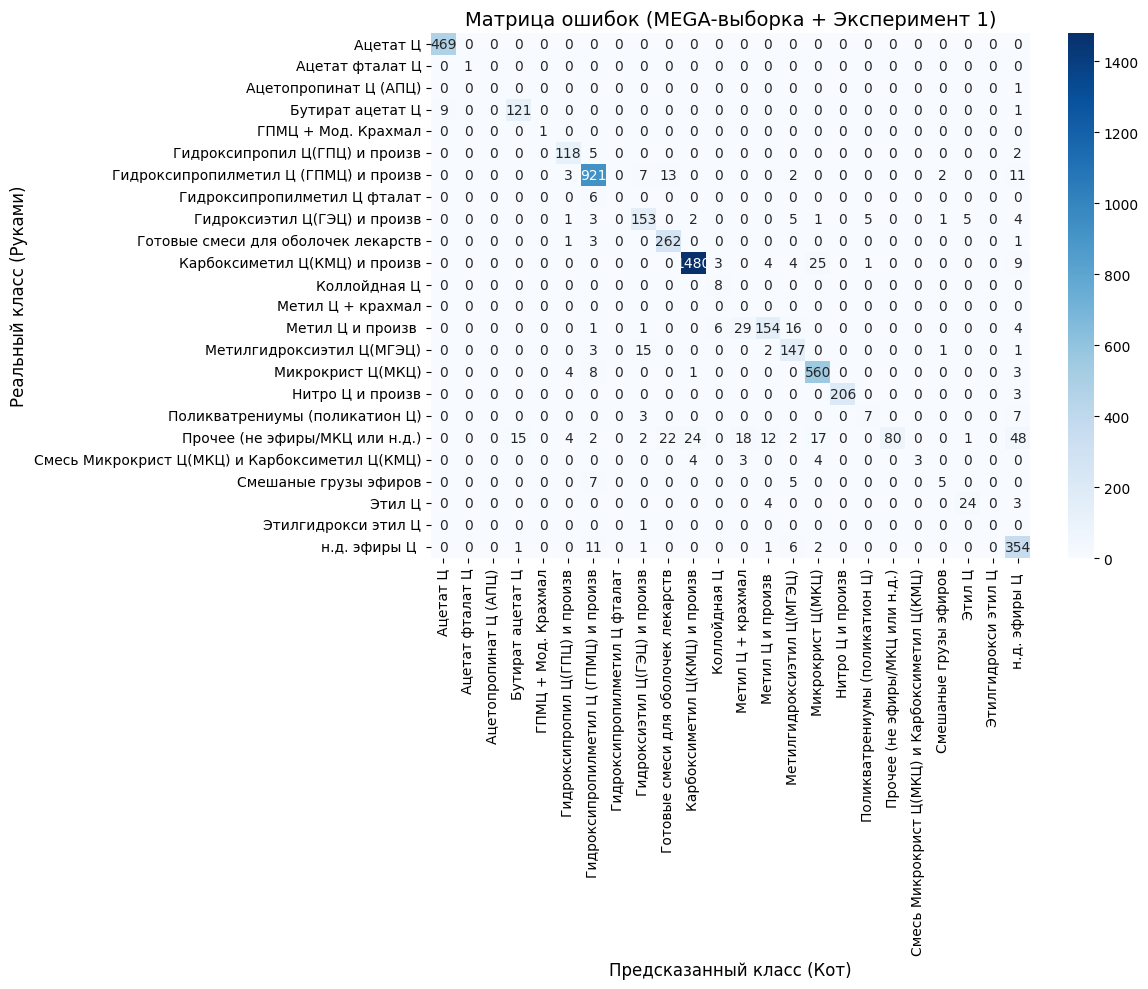


❌ Найдено расхождений среди уверенных ответов: 468 из 5542
Примеры ошибок (Руками vs Кот):


,Описание 350,Реальность (Руками),Предсказание (Кот)
153,ПАЦ НВ (ПОЛИАНИОННАЯ ЦЕЛЛЮЛОЗА НИЗКОЙ ВЯЗКОСТИ...,Карбоксиметил Ц(КМЦ) и произв,Микрокрист Ц(МКЦ)
187,"ЦЕЛЛЮЛОЗА И ЕЕ ХИМИЧЕСКИЕ ПРОИЗВОДНЫЕ, В ПЕРВИ...",Прочее (не эфиры/МКЦ или н.д.),Микрокрист Ц(МКЦ)
213,ДОБАВКА ДЛЯ ПРОИЗВОДСТВА СУХИХ СТРОИТЕЛЬНЫХ СМ...,н.д. эфиры Ц,Гидроксипропилметил Ц (ГПМЦ) и произв
282,ПОЛИАНИОННАЯ ЦЕЛЛЮЛОЗА ПРОМЫШЛЕННОГО НАЗНАЧЕНИ...,Карбоксиметил Ц(КМЦ) и произв,Микрокрист Ц(МКЦ)
333,ПОЛИАНИОННАЯ ЦЕЛЛЮЛОЗА:,Карбоксиметил Ц(КМЦ) и произв,Микрокрист Ц(МКЦ)
341,МЕТИЛГИДРОКСИПРОПИЛЦЕЛЛЮЛОЗА (МЕЦЕЛЛОЗА) - ПОР...,Гидроксипропилметил Ц (ГПМЦ) и произв,Гидроксиэтил Ц(ГЭЦ) и произв
378,"ЭФИРЫ ЦЕЛЛЮЛОЗЫ В ВИДЕ ПОРОШКА БЕЛОГО ЦВЕТА, С...",Метилгидроксиэтил Ц(МГЭЦ),Гидроксипропилметил Ц (ГПМЦ) и произв
379,ПРОСТЫЕ ЭФИРЫ ЦЕЛЛЮЛОЗЫ (МЕТИЛГИДРОКСИЭТИЛЦЕЛЛ...,Метилгидроксиэтил Ц(МГЭЦ),Гидроксиэтил Ц(ГЭЦ) и произв
462,"ПРОЧИЕ ЦЕЛЛЮЛОЗА И ЕЕ ХИМИЧЕСКИЕ ПРОИЗВОДНЫЕ, ...",н.д. эфиры Ц,Микрокрист Ц(МКЦ)
490,"ПОЛИАНИОННАЯ ЦЕЛЛЮЛОЗА ""PETRO PAC-LV"" 85%, НИЗ...",Карбоксиметил Ц(КМЦ) и произв,Микрокрист Ц(МКЦ)



💾 Полный список расхождений сохранен в файл: Анализ_ошибок_MEGA_exp1.xlsx


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. ЗАГРУЖАЕМ ОБА ФАЙЛА
file_manual = 'Произв Целл для проверки Accuracy.xlsx' 
file_pred = 'Hybrid_Result_Cellulose_MEGA_exp1.xlsx' # Наш НОВЫЙ файл с предсказаниями

# Берем правильный лист из ручного файла
df_true = pd.read_excel(file_manual, sheet_name='Выборка в работу (размеченная)')
df_pred = pd.read_excel(file_pred)

# 2. ФИЛЬТРУЕМ КОТА (Берем только уверенные ответы)
df_pred_confident = df_pred[df_pred['продукт единый'] != 'ТРЕБУЕТСЯ LLM'].copy()

print(f"Уверенных строк от Кота для проверки: {len(df_pred_confident)}")

# 3. УМНОЕ ОБЪЕДИНЕНИЕ (Ищем пары по тексту)
df_merged = pd.merge(
    df_true[['Описание 350', 'ПРОДУКТ ЕДИНЫЙ']], 
    df_pred_confident[['Описание 350 крт', 'продукт единый']], 
    left_on='Описание 350', 
    right_on='Описание 350 крт', 
    how='inner' 
)

df_merged = df_merged.rename(columns={
    'ПРОДУКТ ЕДИНЫЙ': 'Реальность (Руками)',
    'продукт единый': 'Предсказание (Кот)'
})

y_true = df_merged['Реальность (Руками)']
y_pred = df_merged['Предсказание (Кот)']

print(f"✅ Успешно сопоставлено строк (нашлось в обоих файлах): {len(df_merged)}")

# 4. ВЫВОДИМ БАЗОВЫЕ МЕТРИКИ
accuracy = accuracy_score(y_true, y_pred)
print(f"\n🎯 Точность уверенных ответов (Accuracy): {accuracy:.2%}")
print("-" * 60)
print("📊 ОТЧЕТ ПО КЛАССАМ (Precision, Recall, F1-Score):")
print(classification_report(y_true, y_pred, zero_division=0)) 

# 5. РИСУЕМ МАТРИЦУ ОШИБОК
plt.figure(figsize=(12, 10))
labels = sorted(list(set(y_true) | set(y_pred)))
cm = confusion_matrix(y_true, y_pred, labels=labels)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=labels, yticklabels=labels)
plt.title('Матрица ошибок (MEGA-выборка + Эксперимент 1)', fontsize=14)
plt.ylabel('Реальный класс (Руками)', fontsize=12)
plt.xlabel('Предсказанный класс (Кот)', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# 6. ВЫВОД И СОХРАНЕНИЕ ОШИБОК
errors_df = df_merged[df_merged['Реальность (Руками)'] != df_merged['Предсказание (Кот)']].copy()

print(f"\n❌ Найдено расхождений среди уверенных ответов: {len(errors_df)} из {len(df_merged)}")
if len(errors_df) > 0:
    print("Примеры ошибок (Руками vs Кот):")
    display(errors_df[['Описание 350', 'Реальность (Руками)', 'Предсказание (Кот)']].head(15))
    
    error_file_path = 'Анализ_ошибок_MEGA_exp1.xlsx'
    errors_df[['Описание 350', 'Реальность (Руками)', 'Предсказание (Кот)']].to_excel(error_file_path, index=False)
    print(f"\n💾 Полный список расхождений сохранен в файл: {error_file_path}")